# Explorador de P_T(k): RG vs. gravedad unimodular con difusión Q

Notebook autocontenido para **correr, graficar y chequear** el cálculo del espectro tensorial primordial
(`derivation.md` → `PROVENANCE.md` sec. 9 y 10). Potencial `V = ½m²φ²`, un solo campo, `Q(N) = Q_i e^(−γN)` acoplado al inflatón (2.9).

**Cómo se usa**
1. Corré la sección 1 (escribe el código en `_nb_src/` y lo importa). El código está en las celdas: podés leerlo y editarlo; si editás una celda, volvela a correr y corré la celda de *recarga*.
2. Las secciones 2 a 6 se corren en orden. Los parámetros se cambian en la sección 2 (`P = Params(...)`).
3. La sección 7 corre los checks (~1 min) y los grafica. La sección 8 es exploración libre.

**Unidades:** `M_P = 1` (reducida, κ=1) y `m = 1` (tiempo en 1/m); `k` en unidades de `m` con `a_i = 1`. La masa física `m_phys = 6e-6 M_P` solo multiplica `P_T` por `m²` al final (exacto por homogeneidad, ver `config.py`).

**Fuente de verdad:** los archivos `.py` de la carpeta `codigo/`. Este notebook los genera `make_notebook.py` y `test_notebook_sync.py` comprueba que coincidan.

**Sobre lo que sale acá:** los resultados de las secciones 3 a 7 son los que están verificados en `PROVENANCE.md` sec. 10 (con los límites de 10.6). La sección 8 es exploración **no verificada**.

## 1. Código

Mapa función → ecuación de `derivation.md` (detalle completo en `PROVENANCE.md` 9.2):

| Módulo | Función | Implementa |
|---|---|---|
| `background.py` | `rho_and_p` | (2.5) |
| | `hubble_rg` / `hubble_ug` | (2.10) / (2.7) |
| | `quantities_rg` / `quantities_ug` | (2.10) KG / (2.9); `Ḣ` como derivada de Friedmann (no usa (2.8)) |
| | `lambda0_from_initial` | (2.11) |
| | `tensor_mass_term` | (4.6): `X = −3H²−2Ḣ−κp+λ̄` |
| `modes.py` | `mode_rhs` | (3.11) con el término de masa de (4.6), en la variable `N` |
| | `bunch_davies_ic` | Bunch–Davies adiabático para (4.8) |
| | `tensor_power` | `P_T = ⟨h_ij h_ij⟩`, `e·e = 2` |
| `checks.py` | `check_*` | ver `PROVENANCE.md` sec. 10 |

Las cinco celdas siguientes escriben los módulos (verbatim de los `.py`). Después viene la celda de importación.

In [1]:
import pathlib
pathlib.Path("_nb_src").mkdir(exist_ok=True)
print("carpeta _nb_src lista")

carpeta _nb_src lista


In [2]:
%%writefile _nb_src/config.py
"""Parámetros del cálculo numérico de P_T(k) en RG y en UG con difusión Q.

Unidades: M_P (reducida) = 1, es decir kappa = 8*pi*G = 1, igual que en derivation.md.
Además se integra con m = 1 (tiempo en unidades de 1/m). Es exacto por homogeneidad: las
ecuaciones (2.7), (2.9), (3.9), (4.8) de derivation.md no cambian de forma bajo
t -> t/m, H -> m H, V -> m^2 V, Q -> m^2 Q, k -> m k. La masa física m_phys solo entra al
final, multiplicando P_T por m_phys^2 (porque P_T ~ H^2/M_P^2).

Decisiones del usuario (sesión 2026-09-20) marcadas con [USUARIO]; el resto son valores por
defecto míos, marcados [DEFECTO], que se documentan en PROVENANCE.md sec. 9 y se pueden cambiar.
"""
from dataclasses import dataclass


@dataclass(frozen=True)
class Params:
    # --- modelo ---------------------------------------------------------------------------
    potential: str = "quadratic" # [USUARIO] "quadratic": V = m^2 phi^2/2 ; "starobinsky": V = (3/4) M^2 (1 - e^{-sqrt(2/3) phi})^2
    m_phys: float = 6e-6         # [USUARIO] escala de masa de V (m en el cuadrático, M en Starobinsky), en M_P. Solo escala P_T.
                                 # Con potential="starobinsky" usar params_for("starobinsky"), que fija M.
    phi_bracket: tuple = (17.0, 40.0)  # [DEFECTO] intervalo donde se busca phi_i (UG dura N_f_ug); depende del potencial
    phi_i: float | None = None   # campo inicial en M_P. None -> se ajusta para que UG dure N_f_ug e-folds
    N_f_ug: float = 100.0        # [USUARIO: 'el más usual en UG'] duración total de la inflación en UG.
                                 # Fuente: A2 Sec. III (N_f >= 65 'as usual'; N_f = 100 en el 1.er escenario)
                                 # y A1 Sec. III (N_min ~ 102 e-folds; ilustra con N_f = 70). Ver PROVENANCE sec. 9.1
    # --- difusión Q(N) = Q_i * exp(-gamma * N), N = ln(a/a_i) ------------------------------
    Q_over_V_i: float = 0.1      # [USUARIO] Q_i / V(phi_i)
    gamma: float = 0.1           # [USUARIO]
    # --- modos ----------------------------------------------------------------------------
    ratio_start: float = 100.0   # [DEFECTO] se arranca cuando k/(aH) = ratio_start (dentro del horizonte)
    ratio_stop: float = 1e-3     # [DEFECTO] se mide P_T cuando k/(aH) = ratio_stop (fuera, congelado)
    n_k: int = 40                # [DEFECTO] modos, equiespaciados en ln k
    # --- integradores ---------------------------------------------------------------------
    rtol_bg: float = 1e-12
    atol_bg: float = 1e-14
    rtol_mode: float = 1e-10
    atol_mode: float = 1e-12
    n_grid_bg: int = 20001       # puntos uniformes en t; se transforman a N para los splines
    t_max: float = 1e3           # tope de tiempo (1/m) para el fondo; el evento eps1=1 corta antes
    workers: int = 8


# [USUARIO 2026-09-21] potencial de Starobinsky. M es una CALIBRACIÓN (no una validación): se fija para que RG reproduzca
# A_s de Planck a N_* = 60 con la fórmula slow-roll escalar de orden cero (M_necesario = 1.143e-5, calculado en
# PROVENANCE sec. 13). Mi valor inicial de memoria (1.3e-5) correspondía a N_* ~ 52 y se descartó antes de correr checks.
M_STAROBINSKY = 1.14e-5
_STARO = dict(potential="starobinsky", m_phys=M_STAROBINSKY, phi_bracket=(5.0, 9.0), t_max=1e4)
# t_max = 1e4 porque con el mismo phi_i RG dura ~390 e-folds (H ~ 0.5 m) y con 1e3 no alcanza eps1 = 1


def params_for(potential: str = "quadratic", **overrides) -> Params:
    """Params con los valores por defecto propios de cada potencial. `overrides` pisa cualquier campo."""
    if potential == "quadratic":
        return Params(**overrides)
    if potential == "starobinsky":
        return Params(**{**_STARO, **overrides})
    raise ValueError(f"potencial desconocido: {potential!r}")

Writing _nb_src/config.py


In [3]:
%%writefile _nb_src/background.py
"""Fondo cosmológico con un inflatón: RG (derivation.md Sec. 2.5) y UG con difusión Q (Secs. 2.4-2.6).

Tiempo cósmico t (decisión ii de derivation.md). Estado y = (phi, phidot, N) con N = ln(a/a_i).
Unidades M_P = 1, m = 1 (ver config.py).

Diseño: RG y UG tienen funciones separadas (`quantities_rg`, `quantities_ug`); ninguna usa la
relación Hdot = -phidot^2/2 de (2.8). Hdot se obtiene derivando en el tiempo la ecuación de
Friedmann de cada modelo ((2.10) o (2.7)) y usando la ecuación del inflatón ((2.10) o (2.9)).
Así (2.8) queda como una consecuencia que se puede contrastar, no como una entrada.
"""
from dataclasses import dataclass, replace

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

from config import Params

LAMBDA_RG = 0.0  # [SUPUESTO] RG sin constante cosmológica: Lambda = 0 en (2.10)
C_STARO = np.sqrt(2.0 / 3.0)  # exponente del potencial de Starobinsky, V ~ (1 - exp(-sqrt(2/3) phi/M_P))^2
POTENTIALS = ("quadratic", "starobinsky")


# ----------------------------------------------------------------------------- potencial
def V(phi, potential="quadratic"):
    """Potencial del inflatón en unidades donde la escala de masa vale 1 (m para el cuadrático, M para Starobinsky).

    quadratic  : V = phi^2/2.                                   [SUPUESTO, decisión del usuario: potencial cuadrático]
    starobinsky: V = (3/4)(1 - exp(-sqrt(2/3) phi))^2.          [SUPUESTO, decisión del usuario 2026-09-21; forma
                 ESTÁNDAR del marco de Einstein de R + R^2/(6M^2) en RG, ver PROVENANCE sec. 13]. Aquí solo se usa la
                 forma del potencial; no se afirma que el origen R^2 valga en UG."""
    if potential == "quadratic":
        return 0.5 * phi**2
    if potential == "starobinsky":
        return 0.75 * (1.0 - np.exp(-C_STARO * phi)) ** 2
    raise ValueError(f"potencial desconocido: {potential!r} (usar {POTENTIALS})")


def dV(phi, potential="quadratic"):
    """V'(phi) del potencial elegido (misma normalización que V)."""
    if potential == "quadratic":
        return phi
    if potential == "starobinsky":
        e = np.exp(-C_STARO * phi)
        return 1.5 * C_STARO * (1.0 - e) * e
    raise ValueError(f"potencial desconocido: {potential!r} (usar {POTENTIALS})")


# ----------------------------------------------------------------------------- materia
def rho_and_p(phi, phid, potential="quadratic"):
    """Densidad y presión del inflatón homogéneo. Implementa derivation.md (2.5) [ESTÁNDAR]."""
    kin = 0.5 * phid**2
    pot = V(phi, potential)
    return kin + pot, kin - pot


# ----------------------------------------------------------------------------- difusión Q
def Q_of_N(N, Q_i, gamma):
    """Q(N) = Q_i exp(-gamma N). [SUPUESTO, decisión del usuario]. Entra en (1.9) y (2.7)."""
    return Q_i * np.exp(-gamma * N)


def Qdot(N, H, Q_i, gamma):
    """dQ/dt = (dQ/dN)(dN/dt) = -gamma Q H, con dN/dt = H. Es el Q-punto de (2.9)."""
    return -gamma * Q_of_N(N, Q_i, gamma) * H


# ----------------------------------------------------------------------------- Hubble
def hubble_rg(rho, Lam=LAMBDA_RG):
    """3 M_P^2 H^2 = rho (+ Lambda M_P^2). Implementa derivation.md (2.10), primera ecuación."""
    return np.sqrt((rho + Lam) / 3.0)


def hubble_ug(rho, Q, Lam0):
    """3 M_P^2 H^2 = rho + Q + Lambda_0 M_P^2. Implementa derivation.md (2.7)."""
    return np.sqrt((rho + Q + Lam0) / 3.0)


def lambda0_from_initial(H_ini, rho_ini, Q_ini):
    """Lambda_0 = 3 H_ini^2 - (rho_ini + Q_ini)/M_P^2. Implementa derivation.md (2.11)."""
    return 3.0 * H_ini**2 - (rho_ini + Q_ini)


# ----------------------------------------------------------------------------- término de masa
def tensor_mass_term(H, Hdot, p, lam_bar):
    """X = -3H^2 - 2 Hdot - kappa p + lambda_bar (kappa = 1).  Implementa derivation.md (4.6).

    Es el coeficiente que multiplica a (a^3 h_ij^2)/(4 kappa) en la acción cuadrática. En la
    ecuación de h entra como  hddot + 3H hdot + (k^2/a^2 - 2X) h = 0.  La derivación dice que
    X = 0 por ecuaciones de fondo relacionadas: es un control interno algebraico, no una prueba independiente de la teoría. Se calcula con las
    cantidades de fondo de cada modelo y lo pasa a la ecuación de modos.
    lam_bar = Lambda (RG) o Lambda_0 + kappa Q(t) (UG)."""
    return -3.0 * H**2 - 2.0 * Hdot - p + lam_bar


# ----------------------------------------------------------------------------- modelos
def quantities_rg(y, potential="quadratic"):
    """Cantidades de fondo en RG a partir de y = (phi, phidot, N).

    phidd: Klein-Gordon estándar, (2.10) tercera ecuación.
    Hdot : derivada temporal de (2.10) primera ecuación, 6 H Hdot = phidot (phiddot + V')."""
    phi, phid, N = y
    rho, p = rho_and_p(phi, phid, potential)
    H = hubble_rg(rho)
    phidd = -3.0 * H * phid - dV(phi, potential)
    Hdot = phid * (phidd + dV(phi, potential)) / (6.0 * H)
    return dict(H=H, phidd=phidd, Hdot=Hdot, p=p, lam_bar=LAMBDA_RG + 0.0 * H)


def quantities_ug(y, Q_i, gamma, Lam0, potential="quadratic"):
    """Cantidades de fondo en UG con difusión a partir de y = (phi, phidot, N).

    phidd: (2.9), Q se acopla solo al inflatón [decisión (a) del usuario].
    Hdot : derivada temporal de (2.7), 6 H Hdot = phidot (phiddot + V') + Qdot."""
    phi, phid, N = y
    rho, p = rho_and_p(phi, phid, potential)
    Q = Q_of_N(N, Q_i, gamma)
    H = hubble_ug(rho, Q, Lam0)
    Qd = Qdot(N, H, Q_i, gamma)
    phidd = -3.0 * H * phid - dV(phi, potential) - Qd / phid
    Hdot = (phid * (phidd + dV(phi, potential)) + Qd) / (6.0 * H)
    return dict(H=H, phidd=phidd, Hdot=Hdot, p=p, lam_bar=Lam0 + Q)


# ----------------------------------------------------------------------------- condiciones iniciales
def initial_state(P: Params):
    """(phi_i, phidot_i, N=0) y datos iniciales comunes a RG y UG.

    [SUPUESTO] phidot_i = -V'/(3 H_SR) con H_SR^2 = V/3 (slow-roll de (2.14) con Q=0, Lambda=0).
    Decisión del usuario: mismo phi_i, phidot_i y mismo H_i en ambos modelos; H_i es el de RG (2.10)."""
    if P.phi_i is None:
        raise ValueError("P.phi_i es None: usar phi_i_for_ug_duration() para fijarlo")
    phi_i = P.phi_i
    phid_i = -dV(phi_i, P.potential) / np.sqrt(3.0 * V(phi_i, P.potential))
    rho_i, _ = rho_and_p(phi_i, phid_i, P.potential)
    H_i = hubble_rg(rho_i)
    Q_i = P.Q_over_V_i * V(phi_i, P.potential)
    Lam0 = lambda0_from_initial(H_i, rho_i, Q_i)  # (2.11): con este H_i sale Lambda_0 = -Q_i
    return dict(y0=np.array([phi_i, phid_i, 0.0]), H_i=H_i, rho_i=rho_i, Q_i=Q_i, Lam0=Lam0)


# ----------------------------------------------------------------------------- integración
@dataclass
class Background:
    """Fondo como funciones de N = ln(a/a_i), listo para integrar los modos."""
    model: str
    N_end: float
    t_end: float
    lnH: CubicSpline
    eps1: CubicSpline
    X_over_H2: CubicSpline
    phi: CubicSpline
    diag: dict


def _solve(model, quantities, y0, P: Params):
    def rhs(t, y):
        q = quantities(y)
        return [y[1], q["phidd"], q["H"]]

    def end_of_inflation(t, y):
        q = quantities(y)
        return -q["Hdot"] / q["H"] ** 2 - 1.0  # eps1 - 1

    end_of_inflation.terminal = True
    end_of_inflation.direction = 1

    sol = solve_ivp(rhs, (0.0, P.t_max), y0, method="DOP853", rtol=P.rtol_bg, atol=P.atol_bg,
                    dense_output=True, events=end_of_inflation)
    if sol.t_events[0].size == 0:
        raise RuntimeError(f"[{model}] no se alcanzó eps1=1 antes de t_max={P.t_max}")
    t_end = float(sol.t_events[0][0])

    # Malla uniforme en t; N(t) no es uniforme y es la abscisa de los splines.
    t = np.linspace(0.0, t_end, P.n_grid_bg)
    Y = sol.sol(t)
    q = quantities(Y)
    X = tensor_mass_term(q["H"], q["Hdot"], q["p"], q["lam_bar"])
    N = Y[2]
    eps1 = -q["Hdot"] / q["H"] ** 2
    if not np.all(np.diff(N) > 0):
        raise RuntimeError(f"[{model}] N(t) no es monótono")
    diag = dict(
        H_i=float(q["H"][0]), eps1_i=float(eps1[0]), N_end=float(N[-1]),
        max_abs_X_over_H2=float(np.max(np.abs(X / q["H"] ** 2))),
        # cantidad que NO se usa en el código y sirve para contrastar (2.8) más adelante:
        max_abs_Hdot_minus_28=float(np.max(np.abs(q["Hdot"] + 0.5 * Y[1] ** 2))),
    )
    return Background(
        model=model, N_end=float(N[-1]), t_end=t_end,
        lnH=CubicSpline(N, np.log(q["H"])),
        eps1=CubicSpline(N, eps1),
        X_over_H2=CubicSpline(N, X / q["H"] ** 2),
        phi=CubicSpline(N, Y[0]),
        diag=diag,
    )


def solve_background_rg(P: Params):
    """Fondo de RG: integra (2.10)."""
    ini = initial_state(P)
    return _solve("RG", lambda y: quantities_rg(y, P.potential), ini["y0"], P)


def solve_background_ug(P: Params):
    """Fondo de UG con difusión: integra (2.9) con H de (2.7) y Q(N) dada."""
    ini = initial_state(P)
    Q_i, gamma, Lam0 = ini["Q_i"], P.gamma, ini["Lam0"]
    bg = _solve("UG", lambda y: quantities_ug(y, Q_i, gamma, Lam0, P.potential), ini["y0"], P)
    bg.diag.update(Q_i=Q_i, Lambda0=Lam0)
    return bg


def phi_i_for_ug_duration(P: Params, bracket=None):
    """phi_i tal que la inflación de UG (eps1 = 1) ocurre en N_end = P.N_f_ug e-folds.

    [SUPUESTO, decisión del usuario] Se fija la duración en UG (valor usual en la literatura de UG, ver config.py);
    RG usa el mismo phi_i y las mismas condiciones iniciales, por lo que dura más. Solo busca una raíz
    sobre solve_background_ug; no interviene ninguna ecuación nueva."""
    bracket = P.phi_bracket if bracket is None else bracket
    f = lambda phi: solve_background_ug(replace(P, phi_i=phi)).N_end - P.N_f_ug
    lo, hi = bracket
    if f(lo) * f(hi) > 0:
        raise ValueError(f"N_end(UG) - {P.N_f_ug} no cambia de signo en phi_i in {bracket}")
    return brentq(f, lo, hi, xtol=1e-10)

Writing _nb_src/background.py


In [4]:
%%writefile _nb_src/modes.py
"""Modos tensoriales: integración numérica de la ecuación de modos y P_T(k).

Implementa derivation.md Secs. 3-4 con la normalización decidida por el usuario
(<h_ij h_ij>, e^lambda_ij e^lambda'_ij = 2 delta, v = a M_P h / sqrt(2), Bunch-Davies).

Variable independiente: N = ln(a/a_i). Se integra v_k (variable canónica de (4.8)) reescalada,
vt = sqrt(2k) v, para que sea O(1) al inicio (los k van de ~1e3 a ~1e26 en unidades de m).

La misma rutina sirve para RG y UG: lo que las distingue son las cantidades de fondo H(N),
eps1(N) y X(N) que entrega cada `Background`. En particular X (término de masa de (4.6)) se
calcula con lambda_bar de cada modelo y ENTRA en la ecuación; el código no supone que se anula.
"""
from concurrent.futures import ProcessPoolExecutor

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

from background import Background
from config import Params


def mode_rhs(N, y, k, bg: Background):
    """Ecuación de modos en N, para y = (vt, dvt/dN).

    Parte de v'' + (k^2 - a''/a - 2 X a^2) v = 0, que es (3.11) con el término de masa de (4.6)
    (' = d/d eta). Con dN = aH d eta, a''/a = a^2 H^2 (2 - eps1) y d(aH)/dN = aH (1 - eps1):
        w_N + (1 - eps1) w + [ k^2/(aH)^2 - (2 - eps1) - 2 X/H^2 ] v = 0,   w = dv/dN.
    (3.11) se obtiene de (3.9) con v = a h; la forma con X viene de la acción (4.6)-(4.8)."""
    vt, w = y
    H = np.exp(bg.lnH(N))
    eps = bg.eps1(N)
    X2 = bg.X_over_H2(N)
    kk = np.exp(2.0 * (np.log(k) - N - bg.lnH(N)))   # (k/aH)^2
    return [w, -(1.0 - eps) * w - (kk - (2.0 - eps) - 2.0 * X2) * vt]


def bunch_davies_ic(k, N_s, bg: Background):
    """Condición inicial de Bunch-Davies (adiabática, orden WKB) en N_s. [SUPUESTO / ESTÁNDAR].

    v = e^{-i int omega d eta} / sqrt(2 omega),  omega^2 = k^2 - a''/a - 2 X a^2  (frecuencia de (4.8)).
    Se desprecia omega' (error relativo ~ (aH/k)^3 ~ 1e-6 con ratio_start = 100).
    En vt = sqrt(2k) v:  vt = sqrt(k/omega),  dvt/dN = v'/(aH) = -i omega/(aH) vt."""
    eps = float(bg.eps1(N_s))
    X2 = float(bg.X_over_H2(N_s))
    # Forma adimensional (sin a ni k^2 sueltos, que desbordan para N >~ 350, como en Starobinsky-RG con ~390 e-folds):
    # q = k/(aH);  omega/(aH) = sqrt(q^2 - (2 - eps) - 2 X/H^2);  vt = sqrt(k/omega) = sqrt(q/(omega/aH)).
    q = np.exp(np.log(k) - N_s - float(bg.lnH(N_s)))
    om = np.sqrt(q**2 - (2.0 - eps) - 2.0 * X2)          # omega/(aH)
    vt = np.sqrt(q / om) + 0j
    w = -1j * om * vt
    return np.array([vt, w], dtype=complex)


def tensor_power(k, vt, N):
    """P_T = <h_ij h_ij> por ln k  =  (k^3/2 pi^2) * 2 * sum_lambda |h_lambda|^2   (M_P = 1).

    Con h_lambda = sqrt(2) v_lambda/(a M_P) (4.6), dos polarizaciones idénticas, v = vt/sqrt(2k):
        P_T = 4 k^3 |v|^2 / (pi^2 a^2) = 2 k^2 |vt|^2 / (pi^2 a^2).
    En de Sitter da 2 H^2/(pi^2 M_P^2) [ESTÁNDAR, sin verificar todavía]."""
    return 2.0 * np.abs(vt) ** 2 * np.exp(2.0 * (np.log(k) - N)) / np.pi**2   # (k/a)^2 sin overflow para N grande


def _horizon_crossing_N(k_over, bg: Background):
    """N donde e^N H(N) = k_over, con e^N H creciente durante la inflación. None si no hay raíz."""
    f = lambda N: N + bg.lnH(N) - np.log(k_over)
    lo, hi = 0.0, bg.N_end
    if f(lo) > 0.0 or f(hi) < 0.0:
        return None
    return brentq(f, lo, hi, xtol=1e-13)


def run_mode(k, bg: Background, P: Params):
    """Integra un modo desde k/(aH)=ratio_start hasta k/(aH)=ratio_stop (o hasta el fin de la inflación)."""
    N_s = _horizon_crossing_N(k / P.ratio_start, bg)
    if N_s is None:
        raise ValueError(f"[{bg.model}] k={k:.3e}: k/ratio_start fuera del rango del fondo (modo empieza antes de N=0)")
    N_f = _horizon_crossing_N(k / P.ratio_stop, bg)
    stopped_early = N_f is None
    if stopped_early:
        N_f = bg.N_end
    y0 = bunch_davies_ic(k, N_s, bg)
    sol = solve_ivp(mode_rhs, (N_s, N_f), y0, method="DOP853", args=(k, bg),
                    rtol=P.rtol_mode, atol=P.atol_mode)
    if not sol.success:
        raise RuntimeError(f"[{bg.model}] k={k:.3e}: {sol.message}")
    vt_f = sol.y[0, -1]
    N_x = _horizon_crossing_N(k, bg)  # salida del horizonte, k = aH
    return dict(
        k=k, N_start=N_s, N_stop=N_f, N_exit=np.nan if N_x is None else N_x,
        ratio_final=k / (np.exp(N_f) * np.exp(bg.lnH(N_f))),
        H_exit=np.nan if N_x is None else float(np.exp(bg.lnH(N_x))),
        eps1_exit=np.nan if N_x is None else float(bg.eps1(N_x)),
        P_T=tensor_power(k, vt_f, N_f),   # en unidades m = 1; se multiplica por m_phys^2 al final
        nfev=sol.nfev, stopped_early=stopped_early,
    )


def _run_mode_star(args):
    return run_mode(*args)


def run_all_modes(ks, bg: Background, P: Params):
    """Corre todos los k (en paralelo si P.workers > 1). Devuelve lista de dicts en el orden de ks."""
    jobs = [(float(k), bg, P) for k in ks]
    if P.workers <= 1:
        return [_run_mode_star(j) for j in jobs]
    with ProcessPoolExecutor(max_workers=P.workers) as ex:
        return list(ex.map(_run_mode_star, jobs, chunksize=1))

Writing _nb_src/modes.py


In [5]:
%%writefile _nb_src/checks.py
"""Checks reproducibles del cálculo de P_T(k) (RG y UG con difusión Q).

Cada `check_*` devuelve un dict {id, title, passed, tolerance, worst, details, source}. Las tolerancias
están fijadas ACÁ, con su justificación, con cambios posteriores documentados para C1.2 y C3.2 (ver PROVENANCE.md
secs. 10 y 13). `run_all()` corre todo y escribe resultados/checks.json; test_checks.py los expone a pytest.

Uso:  python checks.py          (~1-2 min)      |      pytest -q test_checks.py

Referencias externas usadas (textos leídos de las copias de la carpeta del director):
  [MAR]  J. Martin, C. Ringeval, V. Vennin, "Encyclopaedia Inflationaris", arXiv:1303.3787v3:
         Eq. (2.17) P_h = 2k^3|mu_k|^2/(pi^2 a^2); Eq. (2.19) P_h0 = 2H^2/(pi^2 M_Pl^2), P_zeta0 = H^2/(8 pi^2 eps1 M_Pl^2);
         Eqs. (2.20)-(2.25) coeficientes a_i^(T), a_i^(S), C = gamma_E + ln2 - 2 = -0.7296, f = 5 (pivote k* = aH);
         M_Pl^2 = (8 pi G)^(-1) (masa de Planck reducida).
  [TASI] D. Baumann, arXiv:0907.5424v2, Eqs. (196), (198): modo exacto y potencia a tiempo finito.
  [BAU]  D. Baumann, Cosmology (CUP 2022), Eq. (8.127)-(8.128): A_t = 2V/(3 pi^2 M_Pl^4), n_t = -2 eps_V.
  [PLA]  Planck 2018 X (arXiv:1807.06211): "purely quadratic potential always predict a large tensor-to-scalar
         ratio (of roughly 0.15)"; ln(10^10 A_s) = 3.044 +- 0.014 (TT,TE,EE+lowE+lensing).
"""
import json
import os
import platform
import sys
import time
from dataclasses import replace
from functools import lru_cache
from pathlib import Path

import numpy as np
import scipy
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

import background as B
from config import Params, params_for
from modes import run_mode

OUT = Path(__file__).parent / "resultados"

C_SL = np.euler_gamma + np.log(2.0) - 2.0     # [MAR] Eq. (2.20)
F_PIVOT = 5.0                                  # [MAR] Eq. (2.20), pivote k* = aH
A_S_PLANCK = float(np.exp(3.044) * 1e-10)      # [PLA] ln(10^10 A_s) = 3.044
N_EXITS = (12.0, 40.0, 70.0, 85.0)             # N_exit (en RG) de los modos de prueba; cubren el rango de la malla


# ------------------------------------------------------------------------------------------ utilidades
@lru_cache(maxsize=None)
def context(potential="quadratic"):
    """Parámetros por defecto del potencial, con phi_i ajustado (N_f(UG)=100), y los fondos de RG y UG."""
    P = params_for(potential)
    P = replace(P, phi_i=B.phi_i_for_ug_duration(P))
    return P, B.solve_background_rg(P), B.solve_background_ug(P)


def k_at_exit(bg, N):
    """k comóvil que sale del horizonte (k = aH) en N."""
    return float(np.exp(N + bg.lnH(N)))


def eps2_at(bg, N):
    """eps2 = d ln(eps1)/dN (flujo de Hubble). Derivada del spline de eps1."""
    return float(bg.eps1.derivative()(N) / bg.eps1(N))


def a0_tensor(eps1, eps2, order):
    """a0^(T) de [MAR] Eq. (2.23) truncado en `order` (0, 1 o 2)."""
    C, f = C_SL, F_PIVOT
    a = 1.0
    if order >= 1:
        a += -2.0 * (C + 1.0) * eps1
    if order >= 2:
        a += (2 * C**2 + 2 * C + np.pi**2 / 2 - f) * eps1**2 + (-C**2 - 2 * C + np.pi**2 / 12 - 2.0) * eps1 * eps2
    return a


def a1_tensor(eps1, eps2):
    """a1^(T) de [MAR] Eq. (2.24). n_T = a1/a0 en el pivote."""
    C = C_SL
    return -2.0 * eps1 + 2.0 * (2 * C + 1.0) * eps1**2 - 2.0 * (C + 1.0) * eps1 * eps2


def _sr_exits(potential, bg):
    """N_exit (desde el inicio) de los modos de C1.2. Cuadrático: los originales (20, 60, 100, 140). Starobinsky: RG dura ~387
    e-folds y las primeras ~300 son un plateau con eps1 ~ 1e-6 (el check sería trivial); se usan 90, 60, 40, 20 e-folds
    ANTES del final de RG, donde eps1 ~ 1e-4..1e-3."""
    if potential == "quadratic":
        return (20.0, 60.0, 100.0, 140.0)
    return tuple(bg.N_end - n for n in (90.0, 60.0, 40.0, 20.0))


def _result(cid, title, passed, tolerance, worst, details, source):
    return dict(id=cid, title=title, passed=bool(passed), tolerance=tolerance,
                worst=float(worst), details=details, source=source)


def _de_sitter_background(H0=1.0, N_end=40.0):
    """Fondo artificial de de Sitter exacto: H = H0, eps1 = 0, X = 0. Solo para C1.1."""
    N = np.linspace(0.0, N_end, 401)
    cst = lambda c: CubicSpline(N, np.full_like(N, c))
    return B.Background(model="dS", N_end=N_end, t_end=float("nan"), lnH=cst(np.log(H0)), eps1=cst(0.0),
                        X_over_H2=cst(0.0), phi=cst(0.0), diag={})


# ------------------------------------------------------------------------------------------ C1: límite estándar
def check_de_sitter_exact():
    """C1.1  En de Sitter exacto el modo de Bunch-Davies es analítico:
    |v|^2 = (1/2k)(1 + (aH/k)^2)  =>  P_T = (2H^2/pi^2 M_P^2) (1 + (k/aH)^2)  ([TASI] Eqs. 196, 198; normalización tensorial de este trabajo).
    Prueba a la vez: integrador, condición de Bunch-Davies, normalización de P_T (decisión 3: <h_ij h_ij>, e.e = 2)
    y las ecuaciones n1-n2 (forma en N de la ecuación de modos)."""
    tol = 1e-5   # error esperado de la condición inicial adiabática: ~(aH/k)^3 con ratio_start = 100 -> 1e-6
    P = Params()
    bg = _de_sitter_background()
    rows = []
    for k in (1e3, 1e5, 1e8):
        r = run_mode(k, bg, P)
        exact = 2.0 / np.pi**2 * (1.0 + r["ratio_final"] ** 2)  # H0 = 1
        rows.append(dict(k=k, P_num=r["P_T"], P_exact=exact, rel_err=r["P_T"] / exact - 1.0))
    worst = max(abs(x["rel_err"]) for x in rows)
    return _result("C1.1", "de Sitter exacto: P_T = 2H^2/(pi^2 M_P^2)(1+(k/aH)^2)", worst <= tol,
                   f"|rel_err| <= {tol:g}", worst, rows, "[TASI] arXiv:0907.5424v2, Eqs. 196, 198; normalización tensorial de este trabajo")


def check_slow_roll_rg(potential="quadratic"):
    """C1.2  RG con el potencial elegido (por defecto V = m^2 phi^2/2; ver _sr_exits para Starobinsky): P_T de los modos vs la expansión slow-roll de [MAR] Eqs. (2.19),(2.23),
    con H, eps1, eps2 evaluados en k = aH. Se exige que el residuo a segundo orden sea O(eps^3).
    Tolerancia: |P/P_NNLO - 1| <= 30 eps1^3 + 2e-5 (piso numérico: error de la condición inicial ~ 1e-6 y
    del pivote); además |P/P_NLO - 1| <= 20 eps1 max(eps1, |eps2|/2).
    Nota (2026-09-21): la cota NLO original era 20 eps1^2. El residuo de truncar en NLO es O(eps1^2, eps1 eps2) por
    [MAR] (2.23) (coeficiente de eps1 eps2 = -0.25). En el cuadrático eps2 ~ 2 eps1 y ambas cotas coinciden; en Starobinsky
    eps2 >> eps1 y la cota original fallaba por construcción (residuo NLO 1.5e-6 = -0.25 eps1 eps2, como predice (2.23)). Se
    generalizó DESPUÉS de ver ese fallo; el criterio principal (NNLO) no cambió y pasaba con margen ~100x."""
    P, bg, _ = context(potential)
    rows, worst_ratio = [], 0.0
    ok = True
    for N in _sr_exits(potential, bg):
        k = k_at_exit(bg, N)
        r = run_mode(k, bg, P)
        H, e1, e2 = float(np.exp(bg.lnH(N))), float(bg.eps1(N)), eps2_at(bg, N)
        LO = 2.0 * H**2 / np.pi**2
        res = {o: r["P_T"] / (LO * a0_tensor(e1, e2, o)) - 1.0 for o in (0, 1, 2)}
        tol2, tol1 = 30 * e1**3 + 2e-5, 20 * e1 * max(e1, abs(e2) / 2)
        ok &= abs(res[2]) <= tol2 and abs(res[1]) <= tol1
        worst_ratio = max(worst_ratio, abs(res[2]) / tol2)
        rows.append(dict(N_exit=N, eps1=e1, eps2=e2, resid_LO=res[0], resid_NLO=res[1], resid_NNLO=res[2],
                         tol_NLO=tol1, tol_NNLO=tol2, pred_LO_dev=-2 * (C_SL + 1) * e1))
    return _result("C1.2", "RG phi^2 vs slow-roll de Martin et al. (LO, NLO, NNLO)", ok,
                   "|resid_NNLO| <= 30 eps1^3 + 2e-5 y |resid_NLO| <= 20 eps1 max(eps1,|eps2|/2)", worst_ratio, rows,
                   "[MAR] Eqs. (2.19),(2.23); worst = max(|resid_NNLO|/tol)")


def check_planck_phi2(potential="quadratic"):
    """C1.3  Comparación con las predicciones conocidas de V ∝ phi^2 y con Planck.
    a) r = P_T/P_zeta0 = 16 eps1 (1 + O(eps)) con P_zeta0 = H^2/(8 pi^2 eps1) [MAR 2.19], tolerancia 1.5% (las
       correcciones NLO de P_T y P_zeta0 son ~0.5-1.2%).
    b) r(N*=50..60) en [0.12, 0.17]: Planck dice 'roughly 0.15' para un potencial cuadrático [PLA].
    c) A_s(N*=60) = P_zeta0 con H, eps1 del código y m = 6e-6 M_P a menos de 10% de Planck (2.10e-9): valida el valor de m
       (que en PROVENANCE 9.1 estaba marcado como [ESTÁNDAR, sin verificar]).
    d) n_T de los modos (diferencia finita en ln k) = a1/a0 de [MAR] Eq. (2.24) a 5e-5; el LO -2 eps1 [BAU 8.128] se
       reporta solo como referencia."""
    P, bg, _ = context(potential)
    m2 = P.m_phys**2
    rows, ok, worst = [], True, 0.0
    for Nstar in (50.0, 60.0):
        N = bg.N_end - Nstar
        k = k_at_exit(bg, N)
        PT = run_mode(k, bg, P)["P_T"]
        H, e1, e2 = float(np.exp(bg.lnH(N))), float(bg.eps1(N)), eps2_at(bg, N)
        Pz0 = H**2 / (8 * np.pi**2 * e1)
        r_code = PT / Pz0
        d = 0.25
        lp = np.log(run_mode(k * np.exp(d), bg, P)["P_T"]) - np.log(run_mode(k * np.exp(-d), bg, P)["P_T"])
        nT_code = lp / (2 * d)
        nT_mar = a1_tensor(e1, e2) / a0_tensor(e1, e2, 2)
        row = dict(N_star=Nstar, eps1=e1, r_code=r_code, r_16eps1=16 * e1, r_over_16eps1=r_code / (16 * e1),
                   A_s_code=Pz0 * m2, A_s_Planck=A_S_PLANCK, nT_code=nT_code, nT_martin=nT_mar, nT_LO=-2 * e1)
        ok &= abs(r_code / (16 * e1) - 1) <= 0.015
        ok &= 0.12 <= r_code <= 0.17
        ok &= abs(nT_code - nT_mar) <= 5e-5
        worst = max(worst, abs(r_code / (16 * e1) - 1), abs(nT_code - nT_mar))
        if Nstar == 60.0:
            row["A_s_rel_dev"] = Pz0 * m2 / A_S_PLANCK - 1.0
            ok &= abs(row["A_s_rel_dev"]) <= 0.10
        rows.append(row)
    return _result("C1.3", "phi^2: r, A_s, n_T vs slow-roll y Planck", ok,
                   "|r/16eps1-1|<=1.5%; r in [0.12,0.17]; |A_s/A_s,Planck-1|<=10% (N*=60); |n_T-a1/a0|<=5e-5",
                   worst, rows, "[MAR] 2.19,2.23,2.24; [BAU] 8.128; [PLA] texto Sec. 'quadratic', Table 1")


def check_planck_starobinsky(potential="starobinsky"):
    """C1.3-S  Predicciones conocidas de Starobinsky (RG) contra el código, a N* = 50 y 60 e-folds antes del final de RG.
    a) r = P_T/P_zeta0 con P_zeta0 = H^2/(8 pi^2 eps1) [MAR 2.19] (orden cero en el sector escalar) vs 12/N*^2 [ESTÁNDAR,
       límite N* >> 1 de Starobinsky; sin verificar contra texto]: tolerancia 15% (correcciones O(1/N*) ~ 4/N* hasta ~8%).
    b) n_s = 1 - 2 eps1 - eps2 (orden cero) vs 1 - 2/N*: tolerancia absoluta 3e-3 (correcciones O(1/N*^2) ~ 1e-3).
    c) A_s(N*=60) con M = config.M_STAROBINSKY vs Planck a 10%. OJO: M se CALIBRÓ con este mismo dato (config.py), así que
       c) NO es una validación independiente: solo confirma que la calibración está bien aplicada.
    d) n_T de los modos (dif. finita en ln k) = a1/a0 de [MAR] Eq. (2.24) a 5e-5 (igual que C1.3).
    Tolerancias fijadas antes de correr el check."""
    P, bg, _ = context(potential)
    m2 = P.m_phys**2
    rows, ok, worst = [], True, 0.0
    for Nstar in (50.0, 60.0):
        N = bg.N_end - Nstar
        k = k_at_exit(bg, N)
        PT = run_mode(k, bg, P)["P_T"]
        H, e1, e2 = float(np.exp(bg.lnH(N))), float(bg.eps1(N)), eps2_at(bg, N)
        Pz0 = H**2 / (8 * np.pi**2 * e1)
        r_code, r_ref = PT / Pz0, 12.0 / Nstar**2
        ns_code, ns_ref = 1.0 - 2.0 * e1 - e2, 1.0 - 2.0 / Nstar
        d = 0.25
        lp = np.log(run_mode(k * np.exp(d), bg, P)["P_T"]) - np.log(run_mode(k * np.exp(-d), bg, P)["P_T"])
        nT_code = lp / (2 * d)
        nT_mar = a1_tensor(e1, e2) / a0_tensor(e1, e2, 2)
        row = dict(N_star=Nstar, eps1=e1, eps2=e2, r_code=r_code, r_12_over_N2=r_ref, r_rel=r_code / r_ref - 1.0,
                   ns_code=ns_code, ns_1_minus_2_over_N=ns_ref, ns_diff=ns_code - ns_ref,
                   A_s_code=Pz0 * m2, A_s_Planck=A_S_PLANCK, nT_code=nT_code, nT_martin=nT_mar, nT_LO=-2 * e1)
        ok &= abs(r_code / r_ref - 1) <= 0.15 and abs(ns_code - ns_ref) <= 3e-3 and abs(nT_code - nT_mar) <= 5e-5
        worst = max(worst, abs(r_code / r_ref - 1) / 0.15, abs(ns_code - ns_ref) / 3e-3, abs(nT_code - nT_mar) / 5e-5)
        if Nstar == 60.0:
            row["A_s_rel_dev"] = Pz0 * m2 / A_S_PLANCK - 1.0
            ok &= abs(row["A_s_rel_dev"]) <= 0.10
            worst = max(worst, abs(row["A_s_rel_dev"]) / 0.10)
        rows.append(row)
    return _result("C1.3-S", "Starobinsky: r, n_s, n_T vs 12/N^2, 1-2/N y [MAR]; A_s (calibración)", ok,
                   "|r/(12/N^2)-1|<=15%; |n_s-(1-2/N)|<=3e-3; |n_T-a1/a0|<=5e-5; |A_s/A_s,Planck-1|<=10% (N*=60, calibración)",
                   worst, rows, "[MAR] 2.19, 2.24; Starobinsky N* >> 1 [ESTÁNDAR]; [PLA] A_s; worst = max(err/tol)")


# ------------------------------------------------------------------------------------------ C2: convergencia
def _spectra(Pv, bgs, ks):
    return np.array([[run_mode(k, bg, Pv)["P_T"] for k in ks] for bg in bgs])  # (modelo, k)


def check_convergence(potential="quadratic"):
    """C2  Convergencia: se varía UN parámetro por vez y se compara con un valor 'verdad' más fino, en 4 modos (12,
    40, 70, 85 e-folds desde el inicio) y en RG y UG. Mide el máximo |P/P_verdad - 1|.
    Criterio: el valor por defecto debe estar dentro de la tolerancia indicada.
      rtol_mode (verdad 1e-13) : defecto 1e-10 -> 1e-7
      rtol_bg   (verdad 1e-13) : defecto 1e-12 -> 1e-7
      n_grid_bg (verdad 80001) : defecto 20001 -> 1e-6   (interpolación por splines cúbicos)
      ratio_start (verdad 1000): defecto 100   -> 1e-5   (qué tan adentro del horizonte se arranca)
      ratio_stop  (verdad 1e-4): defecto 1e-3  -> 1e-5   (qué tan afuera se mide; error esperado ~(k/aH)^2)"""
    P, bg_rg, bg_ug = context(potential)
    ks = [k_at_exit(bg_rg, N) for N in N_EXITS]
    base = _spectra(P, (bg_rg, bg_ug), ks)
    scans = [  # (parámetro, valores, verdad, defecto, tol, re-resolver fondo)
        ("rtol_mode", (1e-6, 1e-8, 1e-10, 1e-12), 1e-13, 1e-10, 1e-7, False),
        ("rtol_bg", (1e-8, 1e-10, 1e-12), 1e-13, 1e-12, 1e-7, True),
        ("n_grid_bg", (101, 201, 501, 2001, 20001), 80001, 20001, 1e-6, True),
        ("ratio_start", (30.0, 100.0, 300.0), 1000.0, 100.0, 1e-5, False),
        ("ratio_stop", (1e-2, 1e-3), 1e-4, 1e-3, 1e-5, False),
    ]

    def run(pname, val, resolve):
        Pv = replace(P, **{pname: val})
        bgs = (B.solve_background_rg(Pv), B.solve_background_ug(Pv)) if resolve else (bg_rg, bg_ug)
        return _spectra(Pv, bgs, ks)

    details, ok, worst = {}, True, 0.0
    for pname, vals, truth, default, tol, resolve in scans:
        Pt = run(pname, truth, resolve)
        errs = {}
        for v in vals:
            errs[str(v)] = float(np.max(np.abs(run(pname, v, resolve) / Pt - 1.0)))
        e_def = errs[str(default)]
        ok &= e_def <= tol
        worst = max(worst, e_def / tol)
        details[pname] = dict(truth=truth, default=default, tol=tol, max_rel_err_by_value=errs, default_ok=bool(e_def <= tol))
    details["_N_exits"] = list(N_EXITS)
    details["_default_vs_default"] = float(np.max(np.abs(base / base - 1)))
    return _result("C2", "Convergencia numérica (tolerancias, resolución del fondo, condición inicial, punto de medida)",
                   ok, "ver details[*].tol (por parámetro)", worst, details,
                   "worst = max(err_defecto/tol) sobre parámetros")


# ------------------------------------------------------------------------------------------ C3: UG vs RG
def check_conservative_limit(potential="quadratic"):
    """C3.1  Límite conservativo: con gamma = 0, Q = Q_i = cte y Lambda_0 = -Q_i (2.11) la UG DEBE ser RG exacta
    ([derivation.md] Sec. 1.5, 'UG conservativa'; 2.14). El código de UG y el de RG son distintos, así que esto prueba
    el camino de UG (quantities_ug, hubble_ug, (2.9) con Q-punto, Lambda_0) contra el de RG. Tolerancia 1e-8 en P_T
    y 1e-6 en N_end."""
    P, bg_rg, _ = context(potential)
    bg0 = B.solve_background_ug(replace(P, gamma=0.0))
    ks = [k_at_exit(bg_rg, N) for N in N_EXITS]
    a = _spectra(P, (bg_rg,), ks)[0]
    b = _spectra(P, (bg0,), ks)[0]
    rel = np.abs(b / a - 1.0)
    dN = abs(bg0.N_end - bg_rg.N_end)
    ok = rel.max() <= 1e-8 and dN <= 1e-6
    return _result("C3.1", "UG con gamma=0 (Q cte) == RG", ok, "max|P_UG/P_RG-1|<=1e-8 y |dN_end|<=1e-6", rel.max(),
                   dict(rel_diff=rel.tolist(), N_end_RG=bg_rg.N_end, N_end_UG_gamma0=bg0.N_end, dN_end=dN),
                   "derivation.md 1.5, 2.5, 2.14")


def check_background_28(potential="quadratic"):
    """C3.2  La ecuación (2.8), Hdot = -phidot^2/2, NO se usó para construir el fondo. Se contrasta con la solución
    integrada: -dlnH/dN = phi_N^2/2 (derivadas de los splines de H(N) y phi(N)) en RG y UG. Vale solo si la solución
    obedece (2.7) y (2.9) (o (2.10)). Tolerancia absoluta 1e-6 en 0 <= N <= N_end - 1.
    Nota (2026-09-21): para Starobinsky se juzga desde N = 1. En UG-Starobinsky phidot_i (slow-roll de V sola) está ~30x por
    debajo del atractor de UG y eps1 salta de 5e-6 a 1.3e-3 en DN = 0.05; ahí la interpolación por splines falla (error
    1.6e-5 en N < 0.05) y converge al refinar la malla (1.6e-5, 3.3e-6, 1.0e-6 para n_grid_bg = 2e4, 8e4, 2e5), mientras que
    en la muestra de 4000 puntos con N>=1 el máximo conservado RG/UG es 7.43e-9. El error del primer e-fold se guarda en details pero no se juzga. Decidido DESPUÉS de
    ver el fallo; el cuadrático no cambia."""
    P, bg_rg, bg_ug = context(potential)
    tol, rows, worst = 1e-6, {}, 0.0
    N_min = 0.0 if potential == "quadratic" else 1.0   # ver nota abajo
    for bg in (bg_rg, bg_ug):
        N = np.linspace(N_min, bg.N_end - 1.0, 4000)
        lhs = -bg.lnH.derivative()(N)
        rhs = 0.5 * bg.phi.derivative()(N) ** 2
        err = float(np.max(np.abs(lhs - rhs)))
        rows[bg.model] = dict(max_abs_err=err, N_at_max=float(N[np.argmax(np.abs(lhs - rhs))]), max_eps1=float(np.max(rhs)))
        if N_min > 0.0:   # informativo, NO juzgado: el primer e-fold
            N0 = np.linspace(0.0, N_min, 4000)
            rows[bg.model]["first_efold_max_abs_err_not_judged"] = float(np.max(np.abs(-bg.lnH.derivative()(N0) - 0.5 * bg.phi.derivative()(N0) ** 2)))
        worst = max(worst, err)
    return _result("C3.2", "(2.8) sobre la solución integrada (RG y UG)", worst <= tol, f"max abs <= {tol:g}", worst, rows,
                   "derivation.md (2.8)")


def p_t_cosmic_time(k, model, P):
    """Integrador INDEPENDIENTE: ecuación (3.9) con el término de masa, en tiempo cósmico t y para h (no v), integrada
    junto con el fondo. No usa N como variable independiente, ni v, ni splines, ni las fórmulas n1-n2 (forma en N),
    ni eps1. Solo comparte con modes.py las decisiones (condición de Bunch-Davies adiabática y P_T = <h_ij h_ij>)."""
    ini = B.initial_state(P)
    if model == "RG":
        q = lambda y: B.quantities_rg(y, P.potential)
    else:
        Q_i, gamma, Lam0 = ini["Q_i"], P.gamma, ini["Lam0"]
        q = lambda y: B.quantities_ug(y, Q_i, gamma, Lam0, P.potential)

    def rhs_bg(t, y):
        d = q(y)
        return [y[1], d["phidd"], d["H"]]

    def ev(t, y):
        d = q(y)
        return -d["Hdot"] / d["H"] ** 2 - 1.0
    ev.terminal, ev.direction = True, 1
    sol = solve_ivp(rhs_bg, (0.0, P.t_max), ini["y0"], method="DOP853", rtol=P.rtol_bg, atol=P.atol_bg,
                    dense_output=True, events=ev)
    t_end = float(sol.t_events[0][0])
    lnaH = lambda t: sol.sol(t)[2] + np.log(q(sol.sol(t))["H"])
    t_s = brentq(lambda t: lnaH(t) - np.log(k / P.ratio_start), 0.0, t_end, xtol=1e-14)
    tgt = np.log(k / P.ratio_stop)
    t_f = brentq(lambda t: lnaH(t) - tgt, 0.0, t_end, xtol=1e-14) if lnaH(t_end) >= tgt else t_end

    ys = sol.sol(t_s)
    d = q(ys)
    a, H, Hd = np.exp(ys[2]), d["H"], d["Hdot"]
    X = B.tensor_mass_term(H, Hd, d["p"], d["lam_bar"])
    omega = np.sqrt(k**2 - a**2 * (2 * H**2 + Hd) - 2 * X * a**2)      # a''/a = a^2 (2H^2 + Hdot)
    h0 = 1.0 / (a * np.sqrt(omega)) + 0j                                # h = sqrt(2) v / a, v = 1/sqrt(2 omega)
    hd0 = h0 * (-1j * omega / a - H)                                    # hdot = h'/a, h' = h(-i omega - aH)

    def rhs(t, y):
        yb = y[:3].real
        d = q(yb)
        a, H = np.exp(yb[2]), d["H"]
        X = B.tensor_mass_term(H, d["Hdot"], d["p"], d["lam_bar"])
        return [yb[1], d["phidd"], H, y[4], -3.0 * H * y[4] - (k**2 / a**2 - 2.0 * X) * y[3]]

    # h ~ 1/(a sqrt(omega)) llega a ser ~1e-40 para k grandes, muy por debajo de atol: se integra h/|h0| (la ecuación es
    # lineal, es solo un reescalado) y se deshace al final. La 1.ª versión de este check no lo hacía y falló (ver PROVENANCE 10).
    s0 = abs(h0)
    y0 = np.concatenate([ys, [h0 / s0, hd0 / s0]]).astype(complex)
    s2 = solve_ivp(rhs, (t_s, t_f), y0, method="DOP853", rtol=P.rtol_mode, atol=P.atol_mode)
    return 2.0 * k**3 * (abs(s2.y[3, -1]) * s0) ** 2 / np.pi**2          # P_T = (k^3/2pi^2) 2 (2 |h|^2)


def check_independent_cosmic_time(potential="quadratic"):
    """C3.3  P_T con el integrador independiente en tiempo cósmico (p_t_cosmic_time) vs modes.py, en RG y UG, 4 modos.
    Verifica la traducción a N/v (pasos n1-n2 de PROVENANCE 9.3) y el manejo de splines. Tolerancia 1e-5."""
    P, bg_rg, bg_ug = context(potential)
    ks = [k_at_exit(bg_rg, N) for N in N_EXITS]
    tol, rows, worst = 1e-5, [], 0.0
    for name, bg in (("RG", bg_rg), ("UG", bg_ug)):
        for N, k in zip(N_EXITS, ks):
            a = run_mode(k, bg, P)["P_T"]
            b = p_t_cosmic_time(k, name, P)
            rel = b / a - 1.0
            worst = max(worst, abs(rel))
            rows.append(dict(model=name, N_exit_RG=N, P_modes=a, P_cosmic=b, rel_diff=rel))
    return _result("C3.3", "Integrador independiente (h en t cósmico) vs modes.py", worst <= tol, f"|rel| <= {tol:g}",
                   worst, rows, "derivation.md (3.9), (4.6); PROVENANCE 9.3 n1-n2")


def check_ug_vs_rg_difference(potential="quadratic"):
    """C3.4  Cuantificación de P_T^UG/P_T^RG y descarte de que sea ruido numérico.
    1) Ruido: se recalcula el cociente variando rtol_mode (1e-8, 1e-12), rtol_bg (1e-13), ratio_start (300),
       ratio_stop (1e-4). 'noise' = máx. variación del cociente. Pasa si min|ratio-1| >= 100 * noise.
    2) Atribución: el cociente numérico debe coincidir con el cociente de la fórmula slow-roll NNLO ([MAR] 2.19, 2.23)
       evaluada con H, eps1, eps2 propios de cada modelo en su cruce k = aH. Solo se juzgan (a priori) los modos con
       max(eps1, |eps2|) <= 0.05 en ambos modelos; tolerancia 30*max(eps1)^3 + 2e-5. El resto se reporta."""
    P, bg_rg, bg_ug = context(potential)
    Ns = np.arange(10.0, 91.0, 10.0)
    ks = [k_at_exit(bg_rg, N) for N in Ns]
    ratio = lambda Pv, bgs: (lambda s: s[1] / s[0])(_spectra(Pv, bgs, ks))
    r0 = ratio(P, (bg_rg, bg_ug))
    variants = {}
    for name, kw, resolve in (("rtol_mode=1e-8", dict(rtol_mode=1e-8), False), ("rtol_mode=1e-12", dict(rtol_mode=1e-12), False),
                              ("rtol_bg=1e-13", dict(rtol_bg=1e-13), True), ("ratio_start=300", dict(ratio_start=300.0), False),
                              ("ratio_stop=1e-4", dict(ratio_stop=1e-4), False)):
        Pv = replace(P, **kw)
        bgs = (B.solve_background_rg(Pv), B.solve_background_ug(Pv)) if resolve else (bg_rg, bg_ug)
        variants[name] = float(np.max(np.abs(ratio(Pv, bgs) - r0)))
    noise = max(variants.values())
    signal_min, signal_max = float(np.min(np.abs(r0 - 1))), float(np.max(np.abs(r0 - 1)))
    ok_noise = signal_min >= 100 * noise

    rows, ok_attr, worst_attr = [], True, 0.0
    for N_rg, k, r_num in zip(Ns, ks, r0):
        pred, eps = {}, {}
        for bg in (bg_rg, bg_ug):
            Nx = brentq(lambda n: n + bg.lnH(n) - np.log(k), 0.0, bg.N_end, xtol=1e-13)
            H, e1, e2 = float(np.exp(bg.lnH(Nx))), float(bg.eps1(Nx)), eps2_at(bg, Nx)
            pred[bg.model] = 2 * H**2 / np.pi**2 * a0_tensor(e1, e2, 2)
            eps[bg.model] = (e1, e2)
        r_pred = pred["UG"] / pred["RG"]
        dev = r_num / r_pred - 1.0
        judged = all(max(e1, abs(e2)) <= 0.05 for e1, e2 in eps.values())
        tol = 30 * max(eps["RG"][0], eps["UG"][0]) ** 3 + 2e-5
        if judged:
            ok_attr &= abs(dev) <= tol
            worst_attr = max(worst_attr, abs(dev) / tol)
        rows.append(dict(N_exit_RG=N_rg, ratio_numeric=float(r_num), ratio_slowroll_NNLO=float(r_pred), dev=float(dev),
                         eps1_RG=eps["RG"][0], eps1_UG=eps["UG"][0], eps2_UG=eps["UG"][1], judged=judged, tol=tol))
    return _result("C3.4", "P_T^UG/P_T^RG: magnitud, ruido numérico y atribución al fondo", ok_noise and ok_attr,
                   "min|ratio-1| >= 100*noise; |ratio/ratio_SR - 1| <= 30 eps^3 + 2e-5 (modos con eps<=0.05)",
                   max(noise / signal_min * 100, worst_attr),
                   dict(ratio=[float(x) for x in r0], signal_min=signal_min, signal_max=signal_max, noise_by_variant=variants,
                        noise=noise, signal_over_noise=signal_min / noise if noise > 0 else float("inf"), attribution=rows),
                   "derivation.md (3.9), (4.7); [MAR] 2.19, 2.23")


def check_negative_control(potential="quadratic"):
    """C3.5  Control negativo: ¿el código detecta una diferencia REAL en la ecuación de modos?
    a) Con lambda_bar equivocado (se omite Q, o sea lambda_bar = Lambda_0 en vez de Lambda_0 + Q) el término de masa
       -2X deja de anularse y P_T^UG debe cambiar mucho: se exige un cambio >= 1e-2 (relativo) en algún modo.
    b) Con X forzado a 0 (lo que dice la derivación), P_T no debe cambiar respecto del X calculado: <= 1e-9.
    Juntos muestran que (i) la ausencia de diferencia entre las ecuaciones de modos de UG y RG no es insensibilidad
    del código y (ii) el término de masa calculado es despreciable."""
    P, bg_rg, bg_ug = context(potential)
    ks = [k_at_exit(bg_rg, N) for N in N_EXITS]
    N = bg_ug.lnH.x
    Q = B.Q_of_N(N, bg_ug.diag["Q_i"], P.gamma)
    H2 = np.exp(2 * bg_ug.lnH(N))
    X2 = bg_ug.X_over_H2(N)

    def variant(x_over_h2):
        return B.Background(model="UG*", N_end=bg_ug.N_end, t_end=bg_ug.t_end, lnH=bg_ug.lnH, eps1=bg_ug.eps1,
                            X_over_H2=CubicSpline(N, x_over_h2), phi=bg_ug.phi, diag=bg_ug.diag)
    base = np.array([run_mode(k, bg_ug, P)["P_T"] for k in ks])
    wrong = np.array([run_mode(k, variant(X2 - Q / H2), P)["P_T"] for k in ks])   # lambda_bar = Lambda_0 (sin Q)
    zero = np.array([run_mode(k, variant(np.zeros_like(N)), P)["P_T"] for k in ks])
    d_wrong, d_zero = np.abs(wrong / base - 1), np.abs(zero / base - 1)
    ok = d_wrong.max() >= 1e-2 and d_zero.max() <= 1e-9
    return _result("C3.5", "Control negativo: lambda_bar sin Q cambia P_T; X=0 no", ok,
                   "max cambio (sin Q) >= 1e-2 y max cambio (X=0) <= 1e-9", d_wrong.max(),
                   dict(N_exits=list(N_EXITS), rel_change_wrong_lambda=d_wrong.tolist(), rel_change_X_zero=d_zero.tolist()),
                   "derivation.md (4.6), (2.6)")


def check_mutations_are_detected():
    """C0  Los checks no son vacuos: si se rompe el código a propósito, el check correspondiente debe FALLAR.
      M1  normalización de P_T x2            -> C1.1 (de Sitter) debe fallar
      M2  signo de eps1 en la ecuación de modos ((1-eps1) -> (1+eps1)) -> C3.3 (integrador independiente) y C1.2 deben fallar
      M3  Lambda_0 de (2.11) errado en 0.01% de Q_i -> C3.1 (UG con gamma=0 == RG) debe fallar
    Si el código mutado lanza una excepción, cuenta como detectado (el check no puede pasar).
    Usa unittest.mock.patch sobre funciones de modes.py / background.py; no modifica archivos."""
    from unittest import mock
    import modes as M

    def bad_rhs(N, y, k, bg):
        vt, w = y
        H, eps, X2 = np.exp(bg.lnH(N)), bg.eps1(N), bg.X_over_H2(N)
        kk = np.exp(2.0 * (np.log(k) - N - bg.lnH(N)))
        return [w, -(1.0 + eps) * w - (kk - (2.0 - eps) - 2.0 * X2) * vt]

    good_power = M.tensor_power

    def passed_or_none(fn):
        try:
            return fn()["passed"]
        except Exception as e:        # código mutado que revienta = check que no pasa
            return f"excepcion: {type(e).__name__}"

    rows = {}
    with mock.patch.object(M, "tensor_power", lambda k, vt, N: 2.0 * good_power(k, vt, N)):
        rows["M1_P_T_x2 -> C1.1"] = passed_or_none(check_de_sitter_exact)
    with mock.patch.object(M, "mode_rhs", bad_rhs):
        rows["M2_signo_eps1 -> C3.3"] = passed_or_none(check_independent_cosmic_time)
        rows["M2_signo_eps1 -> C1.2"] = passed_or_none(check_slow_roll_rg)
    with mock.patch.object(B, "lambda0_from_initial", lambda H_ini, rho_ini, Q_ini: 3.0 * H_ini**2 - (rho_ini + Q_ini) + 1e-4 * Q_ini):
        rows["M3_Lambda0_+0.01%Q -> C3.1"] = passed_or_none(check_conservative_limit)
    detected = {k: (v is not True) for k, v in rows.items()}
    return _result("C0", "Control de mutaciones: los checks detectan código roto", all(detected.values()),
                   "cada mutación debe hacer fallar su check", sum(not d for d in detected.values()),
                   dict(mutation_detected=detected, outcome_of_mutated_check=rows), "-")


ALL_CHECKS = [check_mutations_are_detected, check_de_sitter_exact, check_slow_roll_rg, check_planck_phi2, check_convergence,
              check_conservative_limit, check_background_28, check_independent_cosmic_time,
              check_ug_vs_rg_difference, check_negative_control]


# Batería completa para Starobinsky (misma que la del cuadrático salvo C0/C1.1, que no dependen del potencial, y C1.3, que es propio)
STARO_CHECKS = [check_slow_roll_rg, check_planck_starobinsky, check_convergence, check_conservative_limit,
                check_background_28, check_independent_cosmic_time, check_ug_vs_rg_difference, check_negative_control]


def run_all(verbose=True, potential="quadratic"):
    P, bg_rg, bg_ug = context(potential)
    results, t0 = [], time.time()
    for fn in (ALL_CHECKS if potential == "quadratic" else STARO_CHECKS):
        t1 = time.time()
        r = fn() if potential == "quadratic" else fn(potential)
        dt = round(time.time() - t1, 1)   # solo se imprime: guardarlo haría cambiar checks.json (y sus hashes) en cada corrida
        results.append(r)
        if verbose:
            print(f"[{'PASS' if r['passed'] else 'FAIL'}] {r['id']:5s} {r['title']}  (worst={r['worst']:.3g}, {dt} s)")
    meta = dict(python=platform.python_version(), numpy=np.__version__, scipy=scipy.__version__,
                phi_i=P.phi_i, N_end_RG=bg_rg.N_end, N_end_UG=bg_ug.N_end)
    meta["potential"], meta["m_phys"] = potential, P.m_phys
    out = OUT if potential == "quadratic" else OUT / potential   # el cuadrático conserva resultados/checks.json (lo leen las figuras)
    out.mkdir(parents=True, exist_ok=True)
    (out / "checks.json").write_text(json.dumps(dict(meta=meta, checks=results), indent=1, default=float))
    if verbose:
        print(f"{sum(r['passed'] for r in results)}/{len(results)} checks pasan en {time.time() - t0:.1f} s -> {os.path.relpath(out / 'checks.json')}")
    return results


if __name__ == "__main__":
    pot = sys.argv[1] if len(sys.argv) > 1 else "quadratic"
    sys.exit(0 if all(r["passed"] for r in run_all(potential=pot)) else 1)

Writing _nb_src/checks.py


In [6]:
%%writefile _nb_src/run_spectrum.py
"""Calcula P_T(k) en RG y en UG con difusión Q, para el potencial elegido (cuadrático por defecto; o Starobinsky).

Uso:  python run_spectrum.py [quadratic|starobinsky]   (parámetros por defecto de config.py)
Salidas: codigo/resultados/ (cuadrático) o codigo/resultados/starobinsky/: PT_k.npz, PT_k.csv, PT_k.png, fondo.png

No hace verificaciones: solo integra y guarda. Los checks son una etapa posterior.
"""
import time
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from background import phi_i_for_ug_duration, solve_background_rg, solve_background_ug
from config import Params, params_for
from modes import run_all_modes

OUT = Path(__file__).parent / "resultados"


def k_grid(bg_rg, bg_ug, P: Params):
    """Malla común de k (comóvil, unidades de m con a_i = 1), equiespaciada en ln k.

    k_min: margen para q inicial hasta 1000 dentro del fondo, incluso al refinar el vacío.
    k_max: margen para q final hasta 1e-4 dentro de ambos fondos, sin saturar la parada.
    [SUPUESTO] Se compara a igual k comóvil (mismo a_i, mismas condiciones iniciales); la relación entre k
    y "N e-folds antes del fin" es distinta en cada modelo (Sec. 9 de PROVENANCE.md)."""
    aH0 = np.exp(bg_rg.lnH(0.0))
    k_min = 1.01 * max(1000.0, P.ratio_start) * aH0
    aH_end = min(np.exp(bg.N_end + bg.lnH(bg.N_end)) for bg in (bg_rg, bg_ug))
    k_max = 0.99 * min(1e-4, P.ratio_stop) * aH_end
    if k_max <= k_min:
        raise ValueError("rango de k vacío: la inflación dura muy poco para ratio_start/ratio_stop")
    return np.geomspace(k_min, k_max, P.n_k)


def main(P: Params = Params()):
    t0 = time.time()
    outdir = OUT if P.potential == "quadratic" else OUT / P.potential   # el cuadrático conserva resultados/ (lo leen las figuras)
    outdir.mkdir(parents=True, exist_ok=True)

    if P.phi_i is None:
        P = replace(P, phi_i=phi_i_for_ug_duration(P))
        print(f"== phi_i = {P.phi_i:.6f} M_P (ajustado para que UG dure N_f = {P.N_f_ug:g} e-folds) ==")
    bg_rg = solve_background_rg(P)
    bg_ug = solve_background_ug(P)
    print("== Fondo (unidades M_P = 1, m = 1) ==")
    for bg in (bg_rg, bg_ug):
        d = bg.diag
        print(f"  {bg.model}: H_i={d['H_i']:.6g}  eps1_i={d['eps1_i']:.4g}  N_end={d['N_end']:.3f}  "
              f"max|X/H^2|={d['max_abs_X_over_H2']:.2e}  max|Hdot+phidot^2/2|={d['max_abs_Hdot_minus_28']:.2e}")
    print(f"  UG: Q_i={bg_ug.diag['Q_i']:.5g}  Lambda_0={bg_ug.diag['Lambda0']:.5g}")
    print("  (los dos últimos números son diagnósticos crudos, NO los checks formales)")

    ks = k_grid(bg_rg, bg_ug, P)
    print(f"== k: {P.n_k} modos, {ks[0]:.3e} .. {ks[-1]:.3e} (m, a_i=1), ln(kmax/kmin)={np.log(ks[-1]/ks[0]):.2f} ==")

    res = {}
    for bg in (bg_rg, bg_ug):
        t1 = time.time()
        out = run_all_modes(ks, bg, P)
        res[bg.model] = {key: np.array([o[key] for o in out]) for key in out[0]}
        print(f"  {bg.model}: {len(ks)} modos en {time.time()-t1:.1f} s "
              f"(nfev medio {np.mean(res[bg.model]['nfev']):.0f}; "
              f"paradas antes de tiempo: {int(np.sum(res[bg.model]['stopped_early']))})")

    m2 = P.m_phys**2  # P_T ~ H^2/M_P^2 -> escala con m^2
    PT_rg = res["RG"]["P_T"] * m2
    PT_ug = res["UG"]["P_T"] * m2

    np.savez(outdir / "PT_k.npz", k=ks, PT_RG=PT_rg, PT_UG=PT_ug,
             **{f"{m}_{key}": v for m, r in res.items() for key, v in r.items() if key not in ("k", "P_T")},
             params=str(asdict(P)))
    header = "k,PT_RG,PT_UG,ratio_UG_over_RG,N_exit_RG,N_exit_UG,H_exit_RG,H_exit_UG,eps1_exit_RG,eps1_exit_UG"
    table = np.column_stack([ks, PT_rg, PT_ug, PT_ug / PT_rg, res["RG"]["N_exit"], res["UG"]["N_exit"],
                             res["RG"]["H_exit"], res["UG"]["H_exit"], res["RG"]["eps1_exit"], res["UG"]["eps1_exit"]])
    np.savetxt(outdir / "PT_k.csv", table, delimiter=",", header=header, comments="")

    print("== P_T(k) (M_P=1, m_phys = %.1e) ==" % P.m_phys)
    print("   k [m, a_i=1]    N_exit_RG  N_exit_UG      P_T_RG        P_T_UG     UG/RG")
    for i in range(0, P.n_k, max(1, P.n_k // 10)):
        print(f"  {ks[i]:12.4e}   {res['RG']['N_exit'][i]:8.3f}  {res['UG']['N_exit'][i]:8.3f}   "
              f"{PT_rg[i]:.6e}  {PT_ug[i]:.6e}  {PT_ug[i]/PT_rg[i]:.6f}")

    # ---- figuras
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].loglog(ks, PT_rg, "o-", ms=3, label="RG")
    ax[0].loglog(ks, PT_ug, "s--", ms=3, label="UG con Q(N)")
    ax[0].set_xlabel(r"$k$  [$m$, $a_i=1$]"); ax[0].set_ylabel(r"$P_T(k)$"); ax[0].legend()
    ax[1].semilogx(ks, PT_ug / PT_rg, "k.-")
    ax[1].set_xlabel(r"$k$  [$m$, $a_i=1$]"); ax[1].set_ylabel(r"$P_T^{UG}/P_T^{RG}$")
    fig.tight_layout(); fig.savefig(outdir / "PT_k.png", dpi=130); plt.close(fig)

    N_grid = np.linspace(0, min(bg_rg.N_end, bg_ug.N_end), 400)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for bg, st in ((bg_rg, "-"), (bg_ug, "--")):
        ax[0].plot(N_grid, np.exp(bg.lnH(N_grid)), st, label=bg.model)
        ax[1].plot(N_grid, bg.eps1(N_grid), st, label=bg.model)
    ax[0].set_xlabel("N = ln(a/a_i)"); ax[0].set_ylabel("H  [m]"); ax[0].legend()
    ax[1].set_xlabel("N = ln(a/a_i)"); ax[1].set_ylabel(r"$\epsilon_1$"); ax[1].set_yscale("log"); ax[1].legend()
    fig.tight_layout(); fig.savefig(outdir / "fondo.png", dpi=130); plt.close(fig)

    print(f"listo en {time.time()-t0:.1f} s -> {outdir}")


if __name__ == "__main__":
    import sys
    main(params_for(sys.argv[1] if len(sys.argv) > 1 else "quadratic"))

Writing _nb_src/run_spectrum.py


**Importación y recarga** (volvé a correr esta celda después de editar cualquiera de las celdas de arriba, en el mismo orden):

In [7]:
import sys, importlib, pathlib
SRC = pathlib.Path("_nb_src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import config, background, modes, checks, run_spectrum
for _m in (config, background, modes, checks, run_spectrum):      # orden de dependencias
    importlib.reload(_m)

%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from dataclasses import replace
from scipy.integrate import solve_ivp
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

B, M, C = background, modes, checks
Params = config.Params
print("módulos cargados desde", SRC.relative_to(pathlib.Path.cwd()))

módulos cargados desde _nb_src


## 2. Parámetros

Los valores por defecto son los de `config.py`. `phi_i` se ajusta para que **UG dure `N_f = 100` e-folds** (valor usual en A1/A2, `PROVENANCE.md` 9.1); RG usa el mismo `phi_i` y las mismas condiciones iniciales, así que dura más.
Editá acá y volvé a correr de esta celda hacia abajo. Si el paralelismo da problemas en tu sistema, poné `workers=1`.

In [8]:
P = Params(
    # m_phys=6e-6,         # masa del inflatón en M_P (solo escala la amplitud)
    # Q_over_V_i=0.1,      # Q_i / V(phi_i)
    # gamma=0.1,           # Q(N) = Q_i exp(-gamma N)
    # N_f_ug=100.0,        # e-folds de inflación en UG (fija phi_i)
    # ratio_start=100.0,   # k/(aH) inicial (dentro del horizonte)
    # ratio_stop=1e-3,     # k/(aH) al medir P_T (fuera, congelado)
    # n_k=40, workers=8,
)
P = replace(P, phi_i=B.phi_i_for_ug_duration(P))
print(f"phi_i = {P.phi_i:.6f} M_P  (ajustado para que UG dure {P.N_f_ug:g} e-folds)")
P

phi_i = 25.386364 M_P  (ajustado para que UG dure 100 e-folds)


Params(potential='quadratic', m_phys=6e-06, phi_bracket=(17.0, 40.0), phi_i=25.386364173387047, N_f_ug=100.0, Q_over_V_i=0.1, gamma=0.1, ratio_start=100.0, ratio_stop=0.001, n_k=40, rtol_bg=1e-12, atol_bg=1e-14, rtol_mode=1e-10, atol_mode=1e-12, n_grid_bg=20001, t_max=1000.0, workers=8)

## 3. Fondo: RG vs. UG con Q(N)

`H(N)`, `ε₁(N)`, `φ(N)` y el papel de `Q`. Condiciones iniciales idénticas: al inicio los dos coinciden; después `Q(N)` los separa. Notá el salto de `ε₁` de UG en el primer e-fold: la velocidad inicial de slow-roll de RG no está en el atractor de UG.

RG: H_i=10.369  eps1_i=0.0031  N_end=161.831
UG: H_i=10.369  eps1_i=0.0031  N_end=100.000
UG: Q_i=32.223  Lambda_0=-32.223  (Lambda_0 = -Q_i por (2.11))


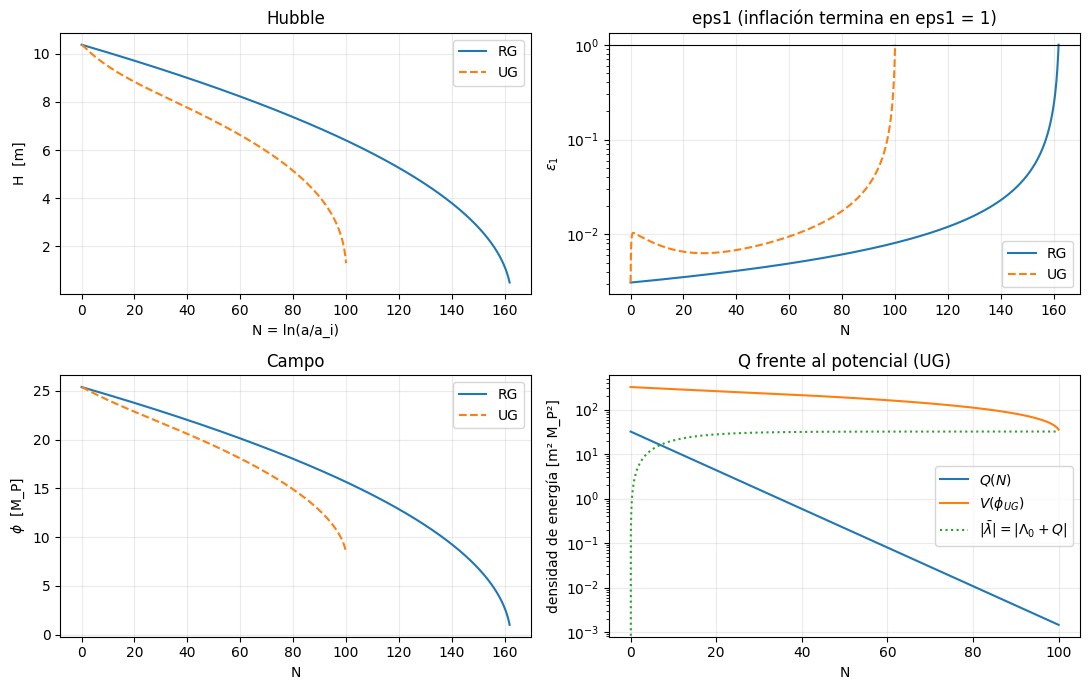

In [9]:
bg_rg = B.solve_background_rg(P)
bg_ug = B.solve_background_ug(P)
for bg in (bg_rg, bg_ug):
    d = bg.diag
    print(f"{bg.model}: H_i={d['H_i']:.5g}  eps1_i={d['eps1_i']:.4g}  N_end={d['N_end']:.3f}")
print(f"UG: Q_i={bg_ug.diag['Q_i']:.5g}  Lambda_0={bg_ug.diag['Lambda0']:.5g}  (Lambda_0 = -Q_i por (2.11))")

N_rg = np.linspace(0, bg_rg.N_end, 2000); N_ug = np.linspace(0, bg_ug.N_end, 2000)
Q_ug = B.Q_of_N(N_ug, bg_ug.diag["Q_i"], P.gamma)
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].plot(N_rg, np.exp(bg_rg.lnH(N_rg)), label="RG"); ax[0, 0].plot(N_ug, np.exp(bg_ug.lnH(N_ug)), "--", label="UG")
ax[0, 0].set(xlabel="N = ln(a/a_i)", ylabel="H  [m]", title="Hubble"); ax[0, 0].legend()
ax[0, 1].semilogy(N_rg, bg_rg.eps1(N_rg), label="RG"); ax[0, 1].semilogy(N_ug, bg_ug.eps1(N_ug), "--", label="UG")
ax[0, 1].axhline(1, color="k", lw=0.8); ax[0, 1].set(xlabel="N", ylabel=r"$\epsilon_1$", title="eps1 (inflación termina en eps1 = 1)"); ax[0, 1].legend()
ax[1, 0].plot(N_rg, bg_rg.phi(N_rg), label="RG"); ax[1, 0].plot(N_ug, bg_ug.phi(N_ug), "--", label="UG")
ax[1, 0].set(xlabel="N", ylabel=r"$\phi$  [M_P]", title="Campo"); ax[1, 0].legend()
ax[1, 1].semilogy(N_ug, Q_ug, label=r"$Q(N)$"); ax[1, 1].semilogy(N_ug, B.V(bg_ug.phi(N_ug)), label=r"$V(\phi_{UG})$")
ax[1, 1].semilogy(N_ug, np.abs(Q_ug - bg_ug.diag["Q_i"]), ":", label=r"$|\bar\lambda| = |\Lambda_0 + Q|$")
ax[1, 1].set(xlabel="N", ylabel="densidad de energía [m² M_P²]", title="Q frente al potencial (UG)"); ax[1, 1].legend()
fig.tight_layout(); plt.show()

### 3b. La ecuación (2.8) sobre la solución integrada

`Ḣ = −φ̇²/2` **no** se usó para construir el fondo (`Ḣ` sale de derivar Friedmann). Acá se contrasta: en `N`, `−d ln H/dN = φ_N²/2` (= `ε₁`). Izquierda: las dos cantidades (se superponen). Derecha: la diferencia (check C3.2, tolerancia 1e-6).

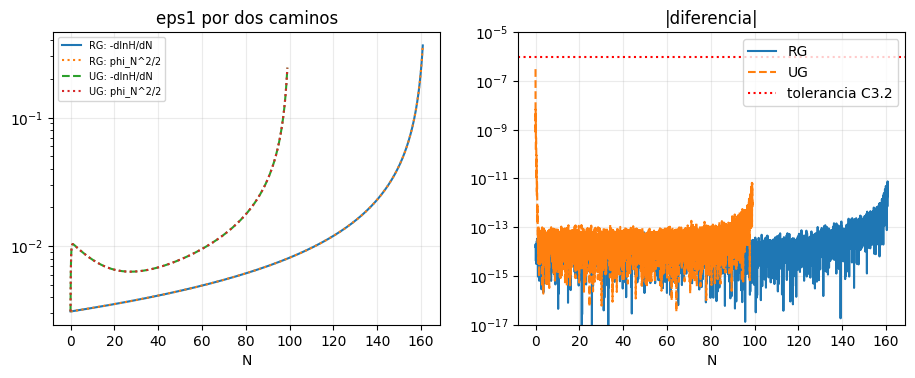

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for bg, st in ((bg_rg, "-"), (bg_ug, "--")):
    N = np.linspace(0, bg.N_end - 1, 4000)
    lhs = -bg.lnH.derivative()(N); rhs = 0.5 * bg.phi.derivative()(N) ** 2
    ax[0].semilogy(N, lhs, st, label=f"{bg.model}: -dlnH/dN"); ax[0].semilogy(N, rhs, ":", label=f"{bg.model}: phi_N^2/2")
    ax[1].semilogy(N, np.abs(lhs - rhs) + 1e-18, st, label=bg.model)
ax[1].axhline(1e-6, color="r", ls=":", label="tolerancia C3.2")
ax[0].set(xlabel="N", title="eps1 por dos caminos"); ax[1].set(xlabel="N", title="|diferencia|", ylim=(1e-17, 1e-5)); ax[0].legend(fontsize=7); ax[1].legend()
plt.show()

## 4. Un modo en detalle

Evolución de un modo `k` a través del cruce del horizonte (`k = aH`, línea vertical). Se integra `ṽ = √(2k) v` con `mode_rhs`, arrancando en `k/(aH) = ratio_start` con Bunch–Davies. Se grafica `P_T(N) ≡ 2k³|h|²/π²` instantáneo (unidades m=1): oscila/decae dentro del horizonte y **se congela** afuera. El valor final es el `P_T(k)` que reporta `run_mode`.

Cambiá `N_exit_demo` (e-folds, medidos en RG, a los que el modo sale del horizonte).

RG: sale del horizonte en N = 40.000;  P_T final = 5.887585e-10
UG: sale del horizonte en N = 40.149;  P_T final = 4.367518e-10


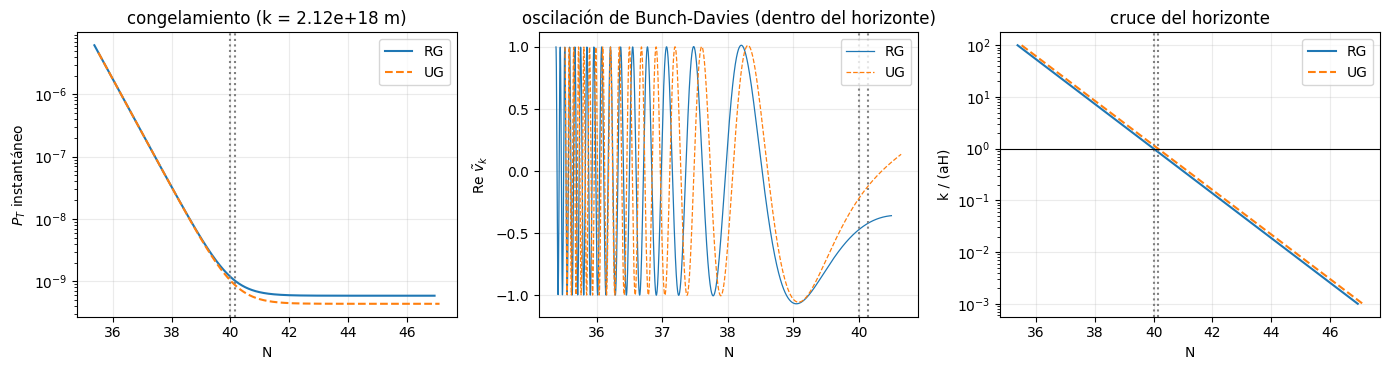

In [11]:
N_exit_demo = 40.0

def mode_history(k, bg, P, n=6000):
    N_s = M._horizon_crossing_N(k / P.ratio_start, bg)
    N_f = M._horizon_crossing_N(k / P.ratio_stop, bg) or bg.N_end
    sol = solve_ivp(M.mode_rhs, (N_s, N_f), M.bunch_davies_ic(k, N_s, bg), method="DOP853", args=(k, bg),
                    rtol=P.rtol_mode, atol=P.atol_mode, dense_output=True)
    N = np.linspace(N_s, N_f, n)
    vt = sol.sol(N)[0]
    h_abs = np.abs(vt) / (np.exp(N) * np.sqrt(k))                # |h| = sqrt(2)|v|/a con v = vt/sqrt(2k)
    return N, vt, 2 * k**3 * h_abs**2 / np.pi**2                 # P_T instantáneo

k_demo = C.k_at_exit(bg_rg, N_exit_demo)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for bg, st in ((bg_rg, "-"), (bg_ug, "--")):
    N, vt, PT_t = mode_history(k_demo, bg, P)
    Nx = M._horizon_crossing_N(k_demo, bg)
    ax[0].semilogy(N, PT_t * P.m_phys**2, st, label=bg.model); ax[0].axvline(Nx, color="gray", ls=":")
    inside = N <= Nx + 0.5                                       # dentro del horizonte (y un poco después del cruce)
    ax[1].plot(N[inside], vt.real[inside], st, lw=0.9, label=bg.model); ax[1].axvline(Nx, color="gray", ls=":")
    ax[2].semilogy(N, k_demo / (np.exp(N) * np.exp(bg.lnH(N))), st, label=bg.model); ax[2].axvline(Nx, color="gray", ls=":")
    print(f"{bg.model}: sale del horizonte en N = {Nx:.3f};  P_T final = {PT_t[-1] * P.m_phys**2:.6e}")
ax[0].set(xlabel="N", ylabel=r"$P_T$ instantáneo", title=f"congelamiento (k = {k_demo:.2e} m)"); ax[0].legend()
ax[1].set(xlabel="N", ylabel=r"Re $\tilde v_k$", title="oscilación de Bunch-Davies (dentro del horizonte)"); ax[1].legend()
ax[2].axhline(1, color="k", lw=0.8); ax[2].set(xlabel="N", ylabel="k / (aH)", title="cruce del horizonte"); ax[2].legend()
fig.tight_layout(); plt.show()

## 5. Espectro P_T(k), RG vs. UG

Malla común de `k` (mismo `a_i`, mismas condiciones iniciales). Se integran todos los modos con `run_all_modes` (paralelo). Salidas: `P_T(k)`, el cociente UG/RG, y la comparación con la fórmula slow-roll de LO, `2H²/π²` en `k = aH` (con `H` en el cruce).

40 modos, k de 1.047e+04 a 3.480e+39 (rango de 81.8 e-folds)
modos que no llegaron a k/aH = ratio_stop antes del fin: 0 (RG), 0 (UG)


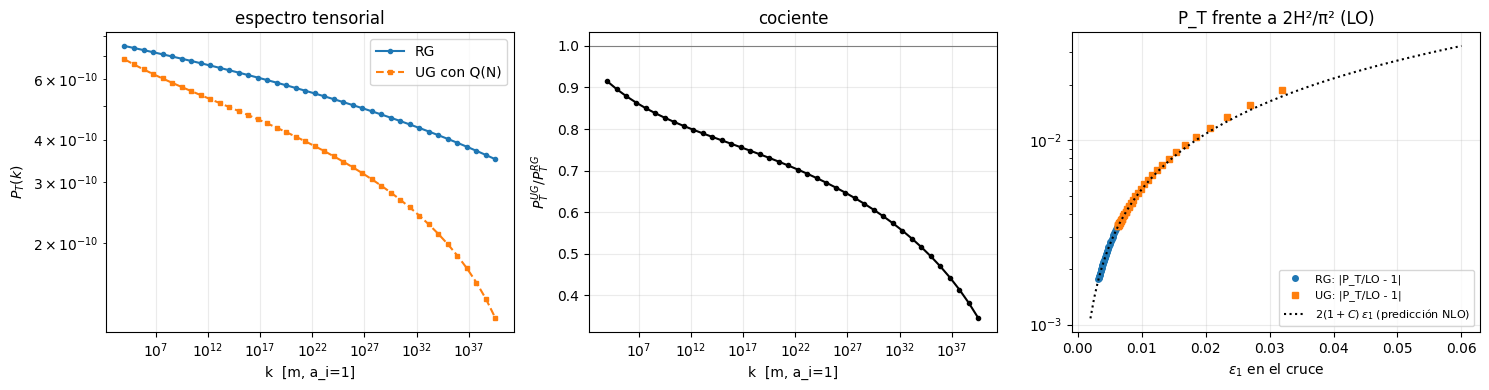

,k,N_exit_RG,N_exit_UG,eps1_exit_RG,eps1_exit_UG,PT_RG,PT_UG,UG_sobre_RG
0,1.047299e+04,6.939674,6.982965,0.003236,0.008537,7.493517e-10,6.852547e-10,0.914463
4,4.605780e+07,15.356531,15.436546,0.003422,0.006971,7.084620e-10,6.025438e-10,0.850496
8,2.025516e+11,23.775055,23.881186,0.003631,0.006370,6.675668e-10,5.390960e-10,0.807554
12,8.907750e+14,32.195456,32.323596,0.003867,0.006404,6.266654e-10,4.843194e-10,0.772852
16,3.917423e+18,40.617989,40.768264,0.004136,0.006880,5.857571e-10,4.330445e-10,0.739290
20,1.722792e+22,49.042962,49.218603,0.004446,0.007736,5.448407e-10,3.827515e-10,0.702502
24,7.576442e+25,57.470759,57.678025,0.004805,0.009034,5.039150e-10,3.321265e-10,0.659092
28,3.331944e+29,65.901858,66.151161,0.005228,0.011005,4.629785e-10,2.802915e-10,0.605409
32,1.465312e+33,74.336874,74.646031,0.005733,0.014255,4.220291e-10,2.263146e-10,0.536254
36,6.444104e+36,82.776611,83.180195,0.006346,0.020628,3.810641e-10,1.686009e-10,0.442448


In [12]:
ks = run_spectrum.k_grid(bg_rg, bg_ug, P)
res = {}
for bg in (bg_rg, bg_ug):
    out = M.run_all_modes(ks, bg, P)
    res[bg.model] = {key: np.array([o[key] for o in out]) for key in out[0]}
m2 = P.m_phys**2
PT_rg, PT_ug = res["RG"]["P_T"] * m2, res["UG"]["P_T"] * m2
print(f"{len(ks)} modos, k de {ks[0]:.3e} a {ks[-1]:.3e} (rango de {np.log(ks[-1]/ks[0]):.1f} e-folds)")
print("modos que no llegaron a k/aH = ratio_stop antes del fin:", int(res['RG']['stopped_early'].sum()), "(RG),", int(res['UG']['stopped_early'].sum()), "(UG)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].loglog(ks, PT_rg, "o-", ms=3, label="RG"); ax[0].loglog(ks, PT_ug, "s--", ms=3, label="UG con Q(N)")
ax[0].set(xlabel="k  [m, a_i=1]", ylabel=r"$P_T(k)$", title="espectro tensorial"); ax[0].legend()
ax[1].semilogx(ks, PT_ug / PT_rg, "k.-"); ax[1].axhline(1, color="gray", lw=0.8)
ax[1].set(xlabel="k  [m, a_i=1]", ylabel=r"$P_T^{UG}/P_T^{RG}$", title="cociente")
for name, st in (("RG", "o"), ("UG", "s")):
    LO = 2 * res[name]["H_exit"] ** 2 / np.pi**2
    ax[2].semilogy(res[name]["eps1_exit"], np.abs(res[name]["P_T"] / LO - 1), st, ms=4, label=f"{name}: |P_T/LO - 1|")
e = np.linspace(2e-3, 0.06, 100)
ax[2].semilogy(e, 2 * (np.euler_gamma + np.log(2) - 1) * e, "k:", label=r"$2(1+C)\,\epsilon_1$ (predicción NLO)")
ax[2].set(xlabel=r"$\epsilon_1$ en el cruce", title="P_T frente a 2H²/π² (LO)"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

pd.DataFrame(dict(k=ks, N_exit_RG=res["RG"]["N_exit"], N_exit_UG=res["UG"]["N_exit"], eps1_exit_RG=res["RG"]["eps1_exit"],
                  eps1_exit_UG=res["UG"]["eps1_exit"], PT_RG=PT_rg, PT_UG=PT_ug, UG_sobre_RG=PT_ug / PT_rg)).iloc[::4]

## 6. Comparación con la literatura para `φ²` (RG)

`r`, `n_T` y `A_s` en `N_* = 50` y `60` e-folds antes del fin de la inflación de RG: check C1.3 (`PROVENANCE.md` 10.3). Referencias: Martin et al. (2.19)–(2.25), Baumann (8.128), Planck 2018 X.

In [13]:
r13 = C.check_planck_phi2()
print("C1.3 pasa:", r13["passed"], "| peor caso:", r13["worst"], "|", r13["tolerance"])
pd.DataFrame(r13["details"])

C1.3 pasa: True | peor caso: 0.0055257752091389944 | |r/16eps1-1|<=1.5%; r in [0.12,0.17]; |A_s/A_s,Planck-1|<=10% (N*=60); |n_T-a1/a0|<=5e-5


,N_star,eps1,r_code,r_16eps1,r_over_16eps1,A_s_code,A_s_Planck,nT_code,nT_martin,nT_LO,A_s_rel_dev
0,50.0,0.010038,0.159713,0.160600,0.994474,1.503465e-09,2.098903e-09,-0.020393,-0.020389,-0.020075,NaN
1,60.0,0.008364,0.133203,0.133817,0.995410,2.166711e-09,2.098903e-09,-0.016947,-0.016945,-0.016727,0.032306


## 7. Checks (`PROVENANCE.md` sec. 10)

Corre los 10 checks (~1 min). Cada uno devuelve `passed`, el peor caso medido y la tolerancia (con revisiones documentadas en el docstring de la función: `C.check_...__doc__`).
Para correr uno solo: `C.check_de_sitter_exact()`, `C.check_slow_roll_rg()`, etc.

In [14]:
results = C.run_all(verbose=True)
R = {r["id"]: r for r in results}
pd.DataFrame([dict(id=r["id"], pasa=r["passed"], peor_caso=r["worst"], tolerancia=r["tolerance"], check=r["title"]) for r in results])

[PASS] C0    Control de mutaciones: los checks detectan código roto  (worst=0, 2.8 s)


[PASS] C1.1  de Sitter exacto: P_T = 2H^2/(pi^2 M_P^2)(1+(k/aH)^2)  (worst=8.71e-07, 0.2 s)


[PASS] C1.2  RG phi^2 vs slow-roll de Martin et al. (LO, NLO, NNLO)  (worst=0.106, 0.3 s)


[PASS] C1.3  phi^2: r, A_s, n_T vs slow-roll y Planck  (worst=0.00553, 0.5 s)


[PASS] C2    Convergencia numérica (tolerancias, resolución del fondo, condición inicial, punto de medida)  (worst=0.0997, 21.6 s)


[PASS] C3.1  UG con gamma=0 (Q cte) == RG  (worst=3.12e-13, 0.7 s)
[PASS] C3.2  (2.8) sobre la solución integrada (RG y UG)  (worst=3.03e-07, 0.0 s)


[PASS] C3.3  Integrador independiente (h en t cósmico) vs modes.py  (worst=4.43e-10, 1.5 s)


[PASS] C3.4  P_T^UG/P_T^RG: magnitud, ruido numérico y atribución al fondo  (worst=0.145, 11.2 s)


[PASS] C3.5  Control negativo: lambda_bar sin Q cambia P_T; X=0 no  (worst=0.603, 0.9 s)
10/10 checks pasan en 39.7 s -> _nb_src/resultados/checks.json


,id,pasa,peor_caso,tolerancia,check
0,C0,True,0.000000e+00,cada mutación debe hacer fallar su check,Control de mutaciones: los checks detectan cód...
1,C1.1,True,8.708398e-07,|rel_err| <= 1e-05,de Sitter exacto: P_T = 2H^2/(pi^2 M_P^2)(1+(k...
2,C1.2,True,1.056565e-01,|resid_NNLO| <= 30 eps1^3 + 2e-5 y |resid_NLO|...,"RG phi^2 vs slow-roll de Martin et al. (LO, NL..."
3,C1.3,True,5.525775e-03,"|r/16eps1-1|<=1.5%; r in [0.12,0.17]; |A_s/A_s...","phi^2: r, A_s, n_T vs slow-roll y Planck"
4,C2,True,9.967149e-02,ver details[*].tol (por parámetro),"Convergencia numérica (tolerancias, resolución..."
5,C3.1,True,3.115286e-13,max|P_UG/P_RG-1|<=1e-8 y |dN_end|<=1e-6,UG con gamma=0 (Q cte) == RG
6,C3.2,True,3.028204e-07,max abs <= 1e-06,(2.8) sobre la solución integrada (RG y UG)
7,C3.3,True,4.425562e-10,|rel| <= 1e-05,Integrador independiente (h en t cósmico) vs m...
8,C3.4,True,1.449497e-01,min|ratio-1| >= 100*noise; |ratio/ratio_SR - 1...,"P_T^UG/P_T^RG: magnitud, ruido numérico y atri..."
9,C3.5,True,6.025491e-01,max cambio (sin Q) >= 1e-2 y max cambio (X=0) ...,Control negativo: lambda_bar sin Q cambia P_T;...


### 7a. C1.2 — RG frente a la expansión slow-roll (LO, NLO, NNLO)
Cada orden reduce el residuo; a NNLO queda por debajo de la tolerancia (línea punteada negra).

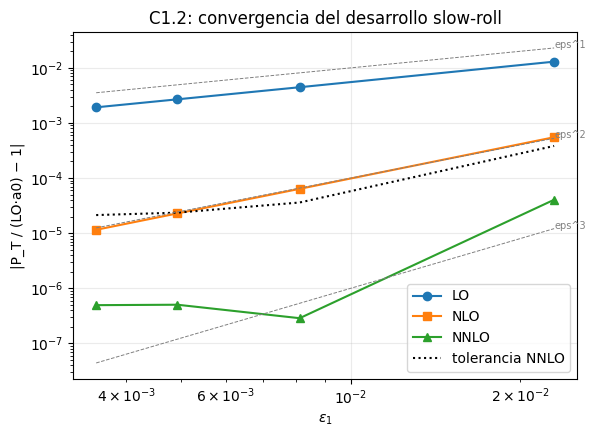

In [15]:
d = R["C1.2"]["details"]; eps = np.array([r["eps1"] for r in d])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for key, lab, st in (("resid_LO", "LO", "o-"), ("resid_NLO", "NLO", "s-"), ("resid_NNLO", "NNLO", "^-")):
    ax.loglog(eps, [abs(r[key]) + 1e-12 for r in d], st, label=lab)
ax.loglog(eps, [r["tol_NNLO"] for r in d], "k:", label="tolerancia NNLO")
for p, st in ((1, "--"), (2, "--"), (3, "--")):
    ax.loglog(eps, eps**p, st, color="gray", lw=0.7); ax.annotate(f"eps^{p}", (eps[-1], eps[-1]**p), fontsize=7, color="gray")
ax.set(xlabel=r"$\epsilon_1$", ylabel="|P_T / (LO·a0) − 1|", title="C1.2: convergencia del desarrollo slow-roll"); ax.legend()
plt.show()

### 7b. C2 — convergencia numérica
Error máximo frente a un valor «verdad» más fino, un parámetro por vez. Rojo: tolerancia. Verde: valor por defecto.

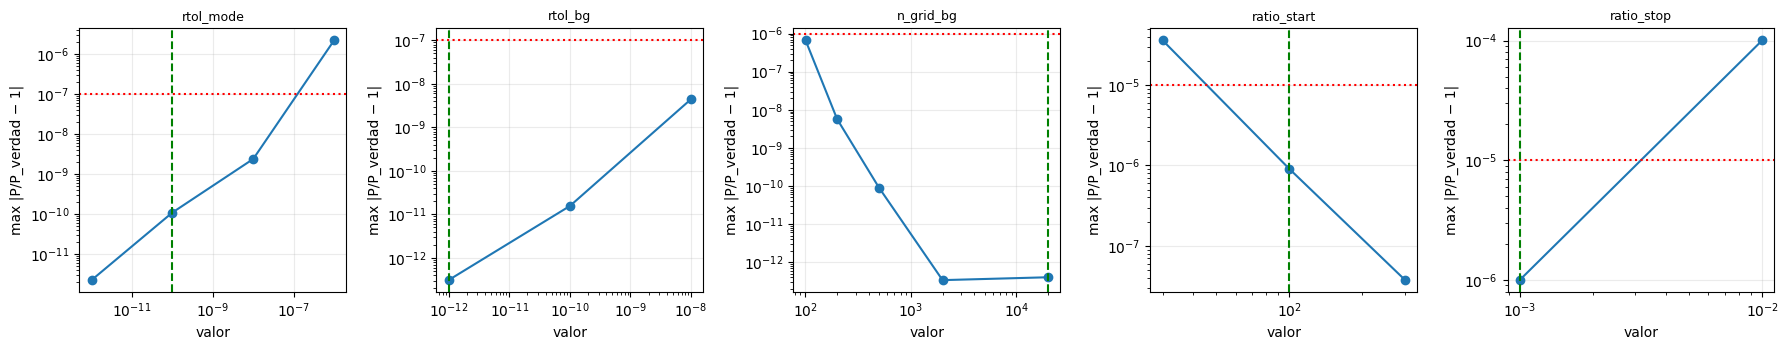

In [16]:
det = R["C2"]["details"]; names = [k for k in det if not k.startswith("_")]
fig, ax = plt.subplots(1, len(names), figsize=(3.6 * len(names), 3.6))
for a, nme in zip(ax, names):
    v = det[nme]; xs = [float(x) for x in v["max_rel_err_by_value"]]; ys = np.array(list(v["max_rel_err_by_value"].values())) + 1e-16
    a.loglog(xs, ys, "o-"); a.axhline(v["tol"], color="r", ls=":"); a.axvline(v["default"], color="g", ls="--"); a.set_title(nme, fontsize=9)
    a.set_xlabel("valor"); a.set_ylabel("max |P/P_verdad − 1|")
fig.tight_layout(); plt.show()

### 7c. C3.4 — el cociente UG/RG y su explicación por el fondo
Izquierda: cociente numérico frente al predicho por la fórmula slow-roll NNLO de RG evaluada con el `H`, `ε₁`, `ε₂` **propios de UG**. Derecha: la diferencia relativa (rojo: tolerancia; los modos con `ε₂ > 0.05` no se juzgan a priori).

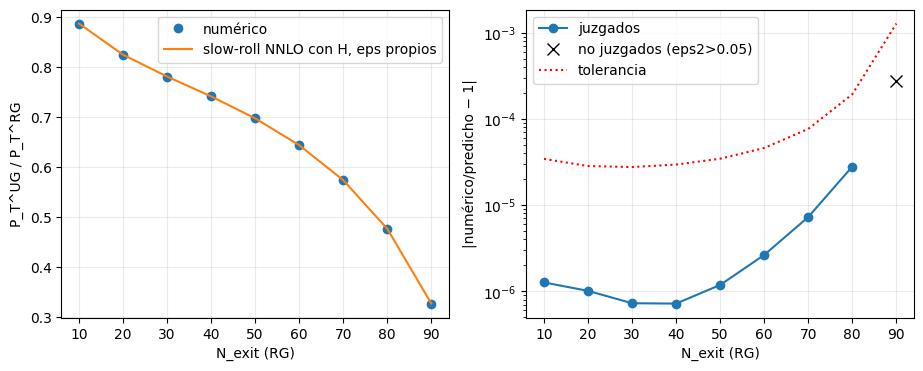

señal mínima |ratio-1| = 0.112;  ruido numérico = 8.50e-07;  señal/ruido = 1.3e+05
variación del cociente por variante numérica: {'rtol_mode=1e-8': 6.7e-10, 'rtol_mode=1e-12': 3.2e-12, 'rtol_bg=1e-13': 2.6e-13, 'ratio_start=300': 8.5e-07, 'ratio_stop=1e-4': 1.6e-08}


In [17]:
d34 = R["C3.4"]["details"]; att = d34["attribution"]; Nx = np.array([r["N_exit_RG"] for r in att])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Nx, [r["ratio_numeric"] for r in att], "o", label="numérico"); ax[0].plot(Nx, [r["ratio_slowroll_NNLO"] for r in att], "-", label="slow-roll NNLO con H, eps propios")
ax[0].set(xlabel="N_exit (RG)", ylabel="P_T^UG / P_T^RG"); ax[0].legend()
judged = np.array([r["judged"] for r in att])
ax[1].semilogy(Nx[judged], [abs(r["dev"]) for r in att if r["judged"]], "o-", label="juzgados")
ax[1].semilogy(Nx[~judged], [abs(r["dev"]) for r in att if not r["judged"]], "x", color="k", ms=9, label="no juzgados (eps2>0.05)")
ax[1].semilogy(Nx, [r["tol"] for r in att], "r:", label="tolerancia")
ax[1].set(xlabel="N_exit (RG)", ylabel="|numérico/predicho − 1|"); ax[1].legend()
plt.show()
print(f"señal mínima |ratio-1| = {d34['signal_min']:.3f};  ruido numérico = {d34['noise']:.2e};  señal/ruido = {d34['signal_over_noise']:.1e}")
print("variación del cociente por variante numérica:", {k: float(f"{v:.1e}") for k, v in d34["noise_by_variant"].items()})

### 7d. C3.5 y C0 — sensibilidad del código y control de mutaciones

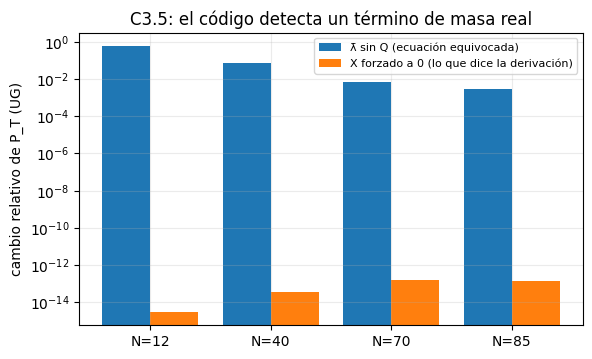

,detectada,resultado_del_check_mutado
M1_P_T_x2 -> C1.1,True,False
M2_signo_eps1 -> C3.3,True,False
M2_signo_eps1 -> C1.2,True,False
M3_Lambda0_+0.01%Q -> C3.1,True,False


In [18]:
d35 = R["C3.5"]["details"]; x = np.arange(len(d35["N_exits"]))
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(x - 0.2, np.array(d35["rel_change_wrong_lambda"]) + 1e-16, 0.4, label="λ̄ sin Q (ecuación equivocada)")
ax.bar(x + 0.2, np.array(d35["rel_change_X_zero"]) + 1e-16, 0.4, label="X forzado a 0 (lo que dice la derivación)")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels([f"N={int(n)}" for n in d35["N_exits"]])
ax.set(ylabel="cambio relativo de P_T (UG)", title="C3.5: el código detecta un término de masa real"); ax.legend(fontsize=8)
plt.show()
pd.DataFrame(dict(detectada=R["C0"]["details"]["mutation_detected"], resultado_del_check_mutado=R["C0"]["details"]["outcome_of_mutated_check"]))

## 8. Exploración libre (**no verificada**, no forma parte de los checks)

Cómo cambia `P_T^UG/P_T^RG` al variar `γ` o `Q_i/V_i`. Esto **no está barrido ni verificado** en `PROVENANCE.md` sec. 10 (ver 10.6, «un solo conjunto de parámetros»); sirve para tener una idea antes de hacerlo bien. Se mantiene `phi_i` fijo (el ajustado arriba), así que la duración de UG cambia con los parámetros. Si un caso no termina la inflación o el modo no cabe, se devuelve `nan`. **Ojo:** cuando `N_end(UG)` (que se imprime abajo) queda cerca de `N_exit`, ese modo sale casi al final de la inflación de UG y el cociente refleja la zona donde slow-roll deja de valer (ver C3.4, modos con `ε₂ > 0.05`), no solo el efecto de `Q`.

gamma → N_end(UG): {0.02: 107.4, 0.05: 100.6, 0.1: 100.0, 0.2: 100.8, 0.5: 102.3}


  Q_over_V_i=0.4: ValueError: [UG] k=2.117e+18: k/ratio_start fuera del rango del fondo (modo empiez
Q_over_V_i → N_end(UG): {0.02: 143.6, 0.05: 124.3, 0.1: 100.0, 0.2: 65.9, 0.4: nan}


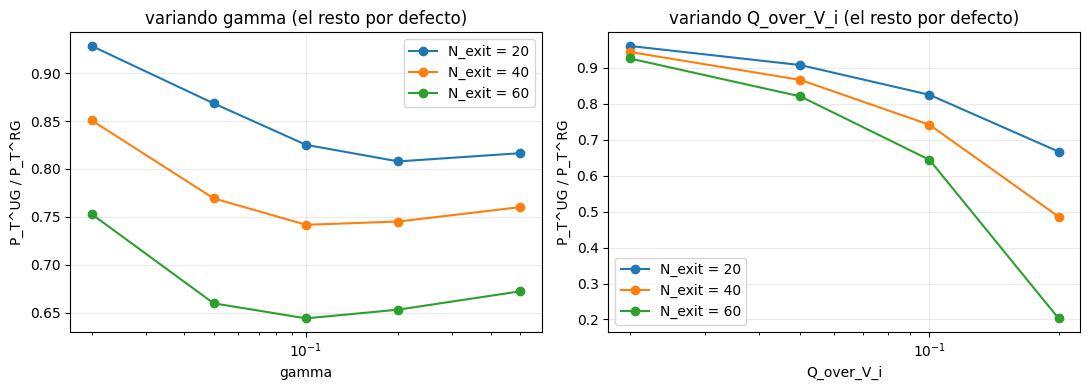

In [19]:
N_exits_scan = (20.0, 40.0, 60.0)

def scan(name, values):
    out = {}
    for v in values:
        Pv = replace(P, **{name: v})
        try:
            b_r, b_u = B.solve_background_rg(Pv), B.solve_background_ug(Pv)
            rat = []
            for N in N_exits_scan:
                k = C.k_at_exit(b_r, N)
                rat.append(M.run_mode(k, b_u, Pv)["P_T"] / M.run_mode(k, b_r, Pv)["P_T"])
            out[v] = (b_u.N_end, rat)
        except Exception as e:
            out[v] = (np.nan, [np.nan] * len(N_exits_scan))
            print(f"  {name}={v}: {type(e).__name__}: {str(e)[:70]}")
    return out

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (name, vals) in zip(ax, (("gamma", (0.02, 0.05, 0.1, 0.2, 0.5)), ("Q_over_V_i", (0.02, 0.05, 0.1, 0.2, 0.4)))):
    r = scan(name, vals)
    xs = list(r)
    for j, N in enumerate(N_exits_scan):
        a.plot(xs, [r[x][1][j] for x in xs], "o-", label=f"N_exit = {N:g}")
    a.set_xscale("log"); a.set(xlabel=name, ylabel="P_T^UG / P_T^RG", title=f"variando {name} (el resto por defecto)"); a.legend()
    print(name, "→ N_end(UG):", {x: round(r[x][0], 1) for x in xs})
fig.tight_layout(); plt.show()